# Real Estate Price Prediction - Ezgi Dönmez

This notebook builds a complete machine learning pipeline for predicting Turkish real estate prices using the Zingat 2020 dataset.

## Datasets:
- `zingat2020_1.csv`: training dataset 
- `zingat2020_2.csv`: test dataset 

## Evaluation Metrics:
- Mean Squared Error (MSE)
- Mean Absolute Percentage Error (MAPE)


## 1. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error,
    make_scorer
)

from sklearn.base import clone

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("LightGBM available:", lgb.__version__)
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM import error:")
    print(e)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost available:", xgb.__version__)
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available:", e)
    
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("CatBoost available")
except Exception as e:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available:", e)
    
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

LightGBM available: 4.6.0
XGBoost available: 3.2.0
CatBoost available


## 2. Load Datasets (Train and Test Separate)

In [2]:
# Load training and test datasets separately
train_df = pd.read_csv("zingat2020_1.csv")
test_df = pd.read_csv("zingat2020_2.csv")

print("="*60)
print("DATASET SHAPES")
print("="*60)
print(f"Training dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print()
print("Training data sample:")
display(train_df.head(3))

DATASET SHAPES
Training dataset shape: (50000, 29)
Test dataset shape: (50000, 29)

Training data sample:


,externalId,title,address,city,district,quarter,price,category,type,url,room,contact,description,bbolum_no,coordinate,is_broker,credit_suitability,deed_type,heating_type,bathroom,building_type,total_floor,usage_status,zoning_status,aidat,rentalIncome,floor,area,age
0,zingat-3208353,KARACAİLYASTA MERKEZE ÇOK YAKIN SATILIK 5.188 ...,Mersin Akdeniz Karacailyas Emek,Mersin,Akdeniz,Karacailyas Emek,625000,Arsa,Bahçe,https://www.zingat.com/karacailyasta-merkeze-c...,NaN,5.079963e+09,DETAYLAR İÇİN ARAYIN GÖRÜŞELİM KAZANÇ GAYRİMNK...,NaN,"36.845125547399,34.705695574066",Company: Kazanç Gayrimenkul BrokerName: Nasip ...,Evet,Müstakil Parsel,NaN,NaN,NaN,NaN,NaN,Bağ & Bahçe,NaN,NaN,NaN,5188,NaN
1,zingat-3117957,REMAX LOCA TATLOG KARŞISI SATILIK DEPOLAMA ALA...,Mersin Akdeniz Toroslar,Mersin,Akdeniz,Toroslar,1780000,Arsa,"Depo, Antrepo İzinli",https://www.zingat.com/remax-loca-tatlog-karsi...,NaN,5.324276e+09,Akdeniz Toroslar Mahallesinde Tren yoluna ceph...,NaN,"36.86834185886,34.754640960554",Company: REMAX LOCA BrokerName: Remax Loca Gay...,Evet,Müstakil Parsel,NaN,NaN,NaN,NaN,NaN,Depo & Antrepo,NaN,NaN,NaN,3800,NaN
2,zingat-3134707,Akdeniz Camili'de Satılık 5540m?zeytin bahçesi,Mersin Akdeniz Camili,Mersin,Akdeniz,Camili,1650000,Arsa,Bahçe,https://www.zingat.com/akdeniz-camilide-satili...,NaN,5.306907e+09,denize ve şehre kuş bakışı5540 m?içersinde 300...,NaN,"36.89181113378,34.619913809001",Company: BAŞAK EMLAK BrokerName: Mersin Başak ...,Hayır,Kat İrtifakı,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5540,NaN


## 3. Exploratory Data Analysis (Training Data Only)

In [3]:
print("="*60)
print("BASIC DATA INFORMATION")
print("="*60)
print("\nTraining data types:")
print(train_df.dtypes)

print("\nMissing values in training data:")
missing_train = pd.DataFrame({
    "missing_count": train_df.isnull().sum(),
    "missing_ratio_percent": train_df.isnull().mean() * 100
}).sort_values("missing_ratio_percent", ascending=False)

display(missing_train)

BASIC DATA INFORMATION

Training data types:
externalId             object
title                  object
address                object
city                   object
district               object
quarter                object
price                   int64
category               object
type                   object
url                    object
room                   object
contact               float64
description            object
bbolum_no             float64
coordinate             object
is_broker              object
credit_suitability     object
deed_type              object
heating_type           object
bathroom               object
building_type          object
total_floor            object
usage_status           object
zoning_status          object
aidat                  object
rentalIncome           object
floor                  object
area                   object
age                    object
dtype: object

Missing values in training data:


,missing_count,missing_ratio_percent
bbolum_no,50000,100.000
zoning_status,45702,91.404
deed_type,44760,89.520
building_type,25730,51.460
aidat,22713,45.426
rentalIncome,20472,40.944
floor,12287,24.574
usage_status,11344,22.688
total_floor,10508,21.016
heating_type,9749,19.498


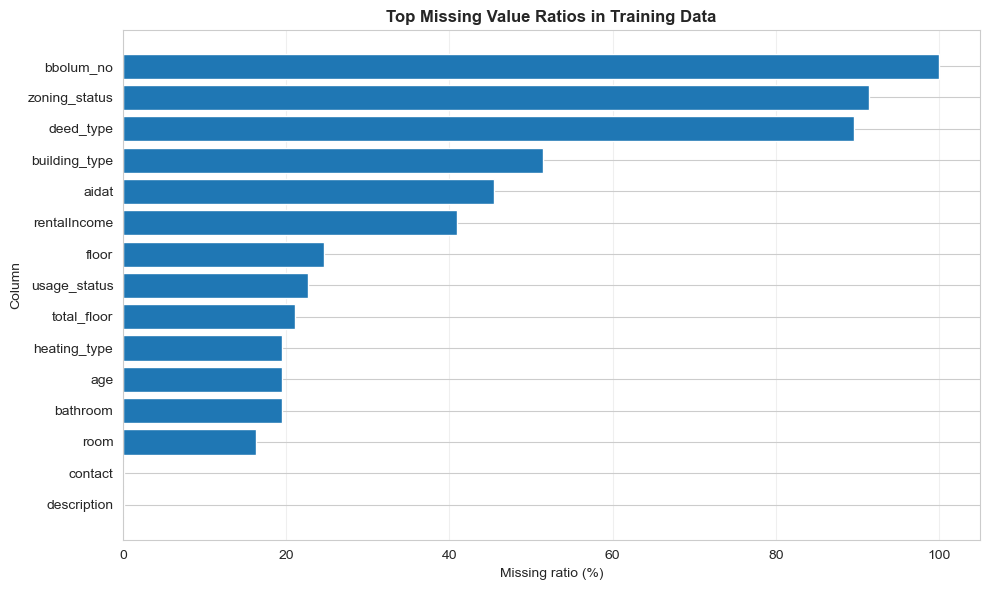

In [ ]:
# EDA Visual: Missing values

missing_ratio = (train_df.isnull().mean() * 100).sort_values(ascending=False)
missing_ratio_nonzero = missing_ratio[missing_ratio > 0]

plt.figure(figsize=(10, 6))
top_missing = missing_ratio_nonzero.head(15).sort_values()

plt.barh(top_missing.index, top_missing.values)
plt.title("Top Missing Value Ratios in Training Data", fontsize=12, fontweight="bold")
plt.xlabel("Missing ratio (%)")
plt.ylabel("Column")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()



TARGET VARIABLE (PRICE) STATISTICS
Missing price values: 0
Non-positive price values: 0


count    5.000000e+04
mean     3.217346e+08
std      7.155418e+10
min      6.000000e+01
1%       4.649750e+04
5%       1.250000e+05
25%      2.500000e+05
50%      4.090000e+05
75%      8.500000e+05
95%      4.950500e+06
99%      2.000000e+07
max      1.600000e+13
Name: price, dtype: float64


Raw price distribution:
  Skewness: 223.6068
  Kurtosis: 49999.9889

Log-transformed price distribution:
  Skewness: 0.8702
  Kurtosis: 4.2372

99th percentile price value: 20,000,000.00


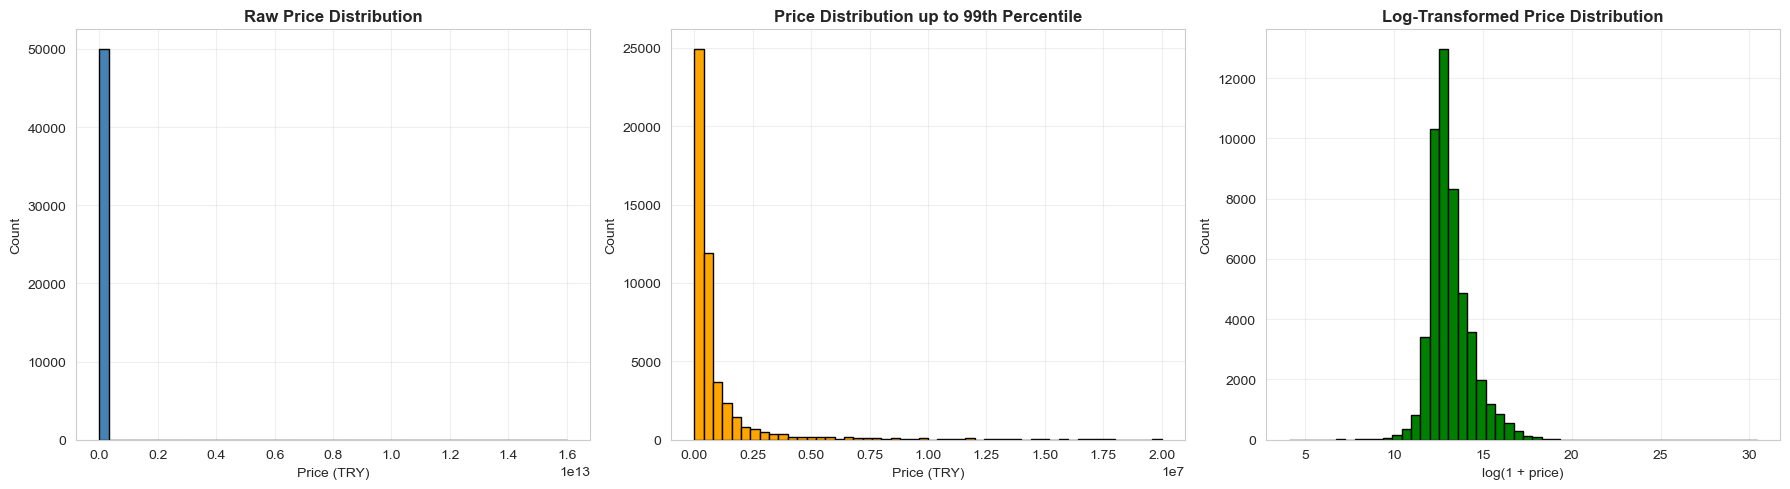

In [4]:
# TARGET VARIABLE ANALYSIS
target = "price"

print("="*60)
print("TARGET VARIABLE (PRICE) STATISTICS")
print("="*60)

# Basic safety checks
print("Missing price values:", train_df[target].isnull().sum())
print("Non-positive price values:", (train_df[target] <= 0).sum())

price_stats = train_df[target].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
display(price_stats)

print(f"\nRaw price distribution:")
print(f"  Skewness: {train_df[target].skew():.4f}")
print(f"  Kurtosis: {train_df[target].kurtosis():.4f}")

# Log-transform target
log_price = np.log1p(train_df[target])

print(f"\nLog-transformed price distribution:")
print(f"  Skewness: {log_price.skew():.4f}")
print(f"  Kurtosis: {log_price.kurtosis():.4f}")

# 99th percentile limit for clearer visualization
price_99 = train_df[target].quantile(0.99)

print(f"\n99th percentile price value: {price_99:,.2f}")

# Visualize raw, clipped, and log-transformed price distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw price distribution
axes[0].hist(train_df[target], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title("Raw Price Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Price (TRY)")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

# Price distribution up to 99th percentile
axes[1].hist(
    train_df.loc[train_df[target] <= price_99, target],
    bins=50,
    color='orange',
    edgecolor='black'
)
axes[1].set_title("Price Distribution up to 99th Percentile", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Price (TRY)")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

# Log-transformed price distribution
axes[2].hist(log_price, bins=50, color='green', edgecolor='black')
axes[2].set_title("Log-Transformed Price Distribution", fontsize=12, fontweight='bold')
axes[2].set_xlabel("log(1 + price)")
axes[2].set_ylabel("Count")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

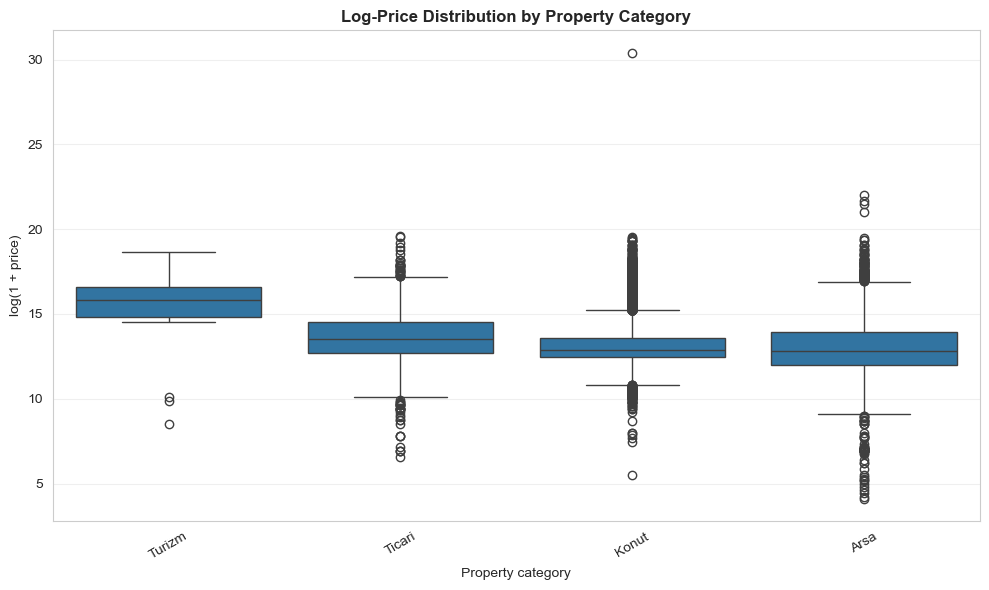

In [ ]:
# EDA Visual: Log-price distribution by category

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train_df,
    x="category",
    y=np.log1p(train_df["price"]),
    order=train_df.groupby("category")["price"].median().sort_values(ascending=False).index
)

plt.title("Log-Price Distribution by Property Category", fontsize=12, fontweight="bold")
plt.xlabel("Property category")
plt.ylabel("log(1 + price)")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

PROPERTY CATEGORY ANALYSIS

Training set category distribution:


category
Konut     40815
Arsa       6619
Ticari     2541
Turizm       25
Name: count, dtype: int64


Test set category distribution (feature distribution check only):


category
Konut     33507
Arsa      12291
Ticari     4114
Turizm       87
Land          1
Name: count, dtype: int64


Train-test category distribution comparison:


,train_count,test_count,train_percent,test_percent
category,,,,
Arsa,6619.0,12291,13.238,24.582
Konut,40815.0,33507,81.630,67.014
Land,0.0,1,0.000,0.002
Ticari,2541.0,4114,5.082,8.228
Turizm,25.0,87,0.050,0.174



Price statistics by category (training data only):


,count,mean,median,min,max,std
category,,,,,,
Turizm,25,1.803160e+07,7500000.0,5000,125000000,2.909916e+07
Ticari,2541,3.043286e+06,750000.0,700,331200000,1.261486e+07
Konut,40815,3.933440e+08,400000.0,245,16000001650000,7.919725e+10
Arsa,6619,3.657438e+06,375000.0,60,3600000000,6.312643e+07


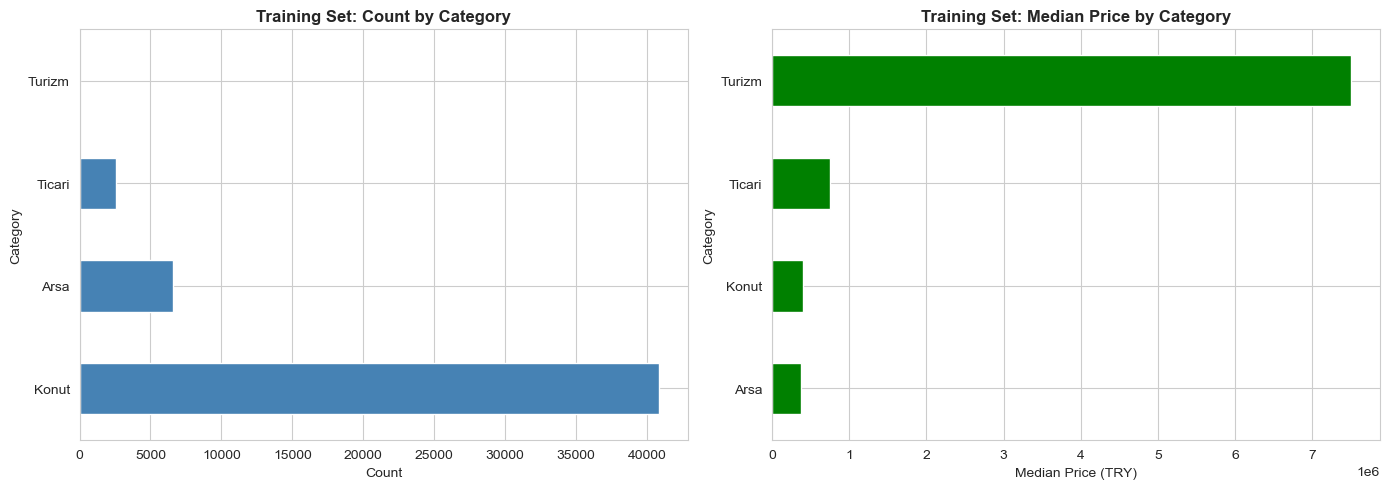

In [5]:
# CATEGORY DISTRIBUTION AND ANALYSIS
print("="*60)
print("PROPERTY CATEGORY ANALYSIS")
print("="*60)

# Training category distribution
print("\nTraining set category distribution:")
cat_counts_train = train_df["category"].value_counts(dropna=False)
display(cat_counts_train)

# Optional: test feature distribution check only
print("\nTest set category distribution (feature distribution check only):")
cat_counts_test = test_df["category"].value_counts(dropna=False)
display(cat_counts_test)

# Compare train and test category percentages
cat_dist_compare = pd.DataFrame({
    "train_count": train_df["category"].value_counts(dropna=False),
    "test_count": test_df["category"].value_counts(dropna=False),
    "train_percent": train_df["category"].value_counts(normalize=True, dropna=False) * 100,
    "test_percent": test_df["category"].value_counts(normalize=True, dropna=False) * 100
}).fillna(0)

print("\nTrain-test category distribution comparison:")
display(cat_dist_compare)

# Price by category: training data only
print("\nPrice statistics by category (training data only):")
price_by_cat = train_df.groupby("category")[target].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

display(price_by_cat.sort_values("median", ascending=False))

# Visualize category count and median price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts_train.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Training Set: Count by Category", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

price_by_cat["median"].sort_values(ascending=True).plot(
    kind="barh",
    ax=axes[1],
    color="green"
)
axes[1].set_title("Training Set: Median Price by Category", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Median Price (TRY)")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()

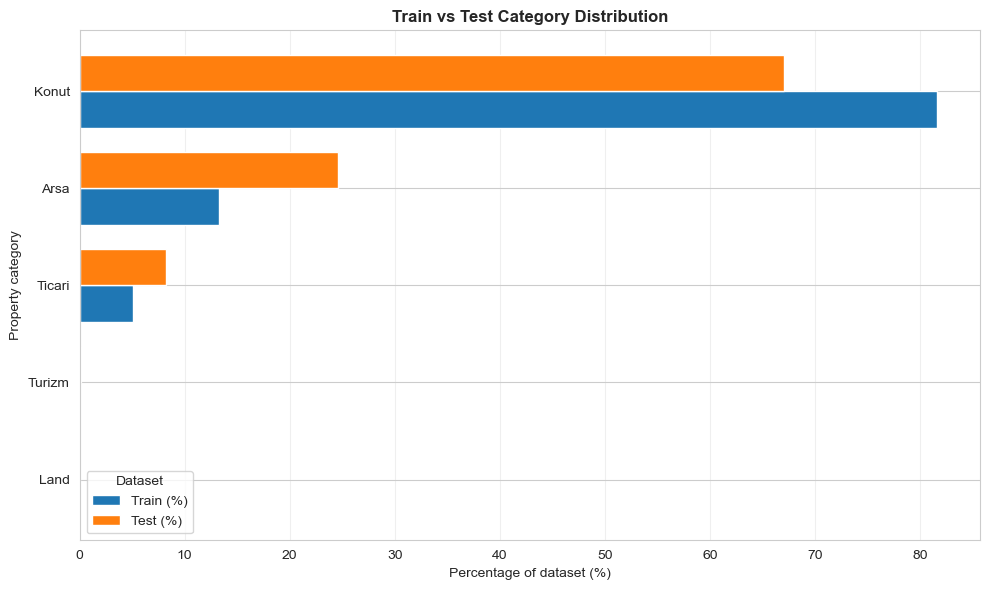

,Train (%),Test (%)
category,,
Land,0.00,0.00
Turizm,0.05,0.17
Ticari,5.08,8.23
Arsa,13.24,24.58
Konut,81.63,67.01


In [ ]:
# EDA Visual: Train vs test category distribution

category_compare_plot = pd.DataFrame({
    "Train (%)": train_df["category"].value_counts(normalize=True, dropna=False) * 100,
    "Test (%)": test_df["category"].value_counts(normalize=True, dropna=False) * 100
}).fillna(0)

category_compare_plot = category_compare_plot.sort_values("Train (%)", ascending=True)

category_compare_plot.plot(
    kind="barh",
    figsize=(10, 6),
    width=0.75
)

plt.title("Train vs Test Category Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Percentage of dataset (%)")
plt.ylabel("Property category")
plt.grid(True, alpha=0.3, axis="x")
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

display(category_compare_plot.round(2))

,Train Count,Test Count,Train %,Test %,Test - Train Difference (pp),Mean Price,Median Price,Min Price,Max Price,Std Price,Mean / Median Ratio
category,,,,,,,,,,,
Konut,40815,33507,81.63%,67.01%,-14.62,"393,344,006","400,000",245,"16,000,001,650,000","79,197,248,281",983.36
Arsa,6619,12292,13.24%,24.58%,+11.35,"3,657,438","375,000",60,"3,600,000,000","63,126,428",9.75
Ticari,2541,4114,5.08%,8.23%,+3.15,"3,043,286","750,000",700,"331,200,000","12,614,861",4.06
Turizm,25,87,0.05%,0.17%,+0.12,"18,031,596","7,500,000","5,000","125,000,000","29,099,159",2.40


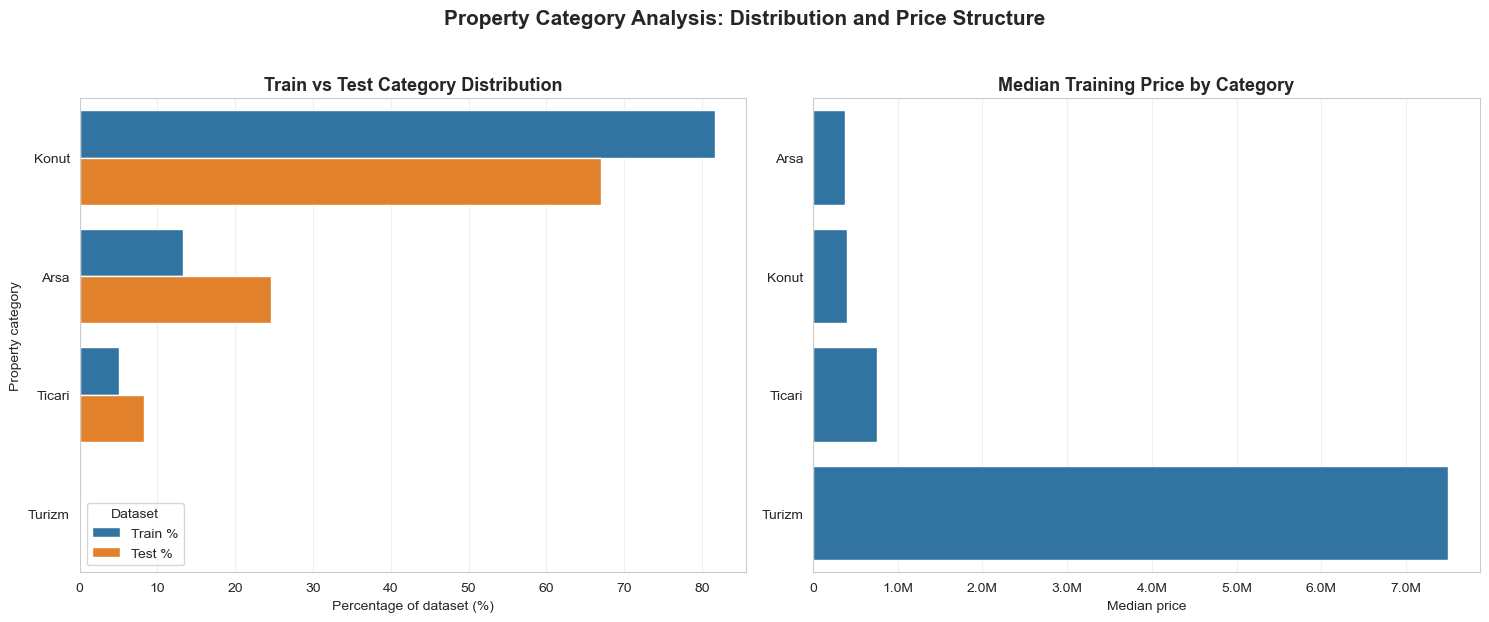

In [ ]:
# Copy category columns
train_cat = train_df["category"].copy()
test_cat = test_df["category"].copy()

# Optional: map test category "Land" to "Arsa" for consistency if it exists
test_cat = test_cat.replace({"Land": "Arsa"})

# Count and percentage comparison
train_counts = train_cat.value_counts()
test_counts = test_cat.value_counts()

category_summary = pd.DataFrame({
    "Train Count": train_counts,
    "Test Count": test_counts
}).fillna(0)

category_summary["Train Count"] = category_summary["Train Count"].astype(int)
category_summary["Test Count"] = category_summary["Test Count"].astype(int)

category_summary["Train %"] = category_summary["Train Count"] / category_summary["Train Count"].sum() * 100
category_summary["Test %"] = category_summary["Test Count"] / category_summary["Test Count"].sum() * 100
category_summary["Test - Train Difference (pp)"] = category_summary["Test %"] - category_summary["Train %"]

# Price statistics from training data only
price_stats = train_df.groupby("category")["price"].agg(
    Count="count",
    Mean_Price="mean",
    Median_Price="median",
    Min_Price="min",
    Max_Price="max",
    Std_Price="std"
)

category_summary = category_summary.join(
    price_stats[["Mean_Price", "Median_Price", "Min_Price", "Max_Price", "Std_Price"]],
    how="left"
)

category_summary["Mean / Median Ratio"] = (
    category_summary["Mean_Price"] / category_summary["Median_Price"]
)

# Sort by train percentage
category_summary = category_summary.sort_values("Train %", ascending=False)

# Display clean formatted table
display_table = category_summary.copy()

display_table = display_table.rename(columns={
    "Mean_Price": "Mean Price",
    "Median_Price": "Median Price",
    "Min_Price": "Min Price",
    "Max_Price": "Max Price",
    "Std_Price": "Std Price"
})

styled_category_table = (
    display_table.style
    .format({
        "Train %": "{:.2f}%",
        "Test %": "{:.2f}%",
        "Test - Train Difference (pp)": "{:+.2f}",
        "Mean Price": "{:,.0f}",
        "Median Price": "{:,.0f}",
        "Min Price": "{:,.0f}",
        "Max Price": "{:,.0f}",
        "Std Price": "{:,.0f}",
        "Mean / Median Ratio": "{:.2f}"
    })
    .background_gradient(
        subset=["Train %", "Test %"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Test - Train Difference (pp)"],
        cmap="coolwarm"
    )
    .background_gradient(
        subset=["Mean / Median Ratio"],
        cmap="Oranges"
    )
    .set_caption("Property Category Distribution and Training Price Statistics")
)

display(styled_category_table)

# Helper function for price axis labels
def price_formatter(x, pos):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    else:
        return f"{x:.0f}"

# Prepare data for plotting
plot_df = display_table.reset_index()

# Make the first column name clean and consistent
plot_df = plot_df.rename(columns={plot_df.columns[0]: "Category"})

# Figure: category distribution + median price
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Train vs test category distribution
plot_melted = plot_df.melt(
    id_vars="Category",
    value_vars=["Train %", "Test %"],
    var_name="Dataset",
    value_name="Percentage"
)

sns.barplot(
    data=plot_melted,
    y="Category",
    x="Percentage",
    hue="Dataset",
    ax=axes[0]
)

axes[0].set_title("Train vs Test Category Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Percentage of dataset (%)")
axes[0].set_ylabel("Property category")
axes[0].grid(True, alpha=0.3, axis="x")
axes[0].legend(title="Dataset")

# Plot 2: Median price by category
price_plot_df = plot_df.sort_values("Median Price", ascending=True)

sns.barplot(
    data=price_plot_df,
    y="Category",
    x="Median Price",
    ax=axes[1]
)

axes[1].set_title("Median Training Price by Category", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Median price")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(FuncFormatter(price_formatter))
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle(
    "Property Category Analysis: Distribution and Price Structure",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()


## 4. Data Cleaning Helper Functions

In [ ]:
# Helper functions to convert text columns to numeric

def parse_turkish_number(x):
    """
    Convert Turkish-formatted numeric text to float.
    Examples:
    '1.500' -> 1500
    '1.500,50' -> 1500.50
    '120,5' -> 120.5
    '120.5' -> 120.5
    """
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    # Remove common text and units
    x = (
        x.replace("TRY", "")
         .replace("TL", "")
         .replace("(aylık)", "")
         .replace("m²", "")
         .replace("m2", "")
         .strip()
    )
    
    # Keep only numbers, comma, dot, and minus sign
    x = re.sub(r"[^0-9,.\-]", "", x)
    
    if x == "":
        return np.nan
    
    # If both dot and comma exist, assume Turkish format: 1.500,50
    if "." in x and "," in x:
        x = x.replace(".", "").replace(",", ".")
    
    # If only comma exists, treat comma as decimal separator
    elif "," in x:
        x = x.replace(",", ".")
    
    # If only dot exists, keep it as decimal point unless it looks like thousands separator
    elif "." in x:
        parts = x.split(".")
        if len(parts) > 1 and all(len(part) == 3 for part in parts[1:]):
            x = x.replace(".", "")
    
    return pd.to_numeric(x, errors="coerce")


def clean_money_column(x):
    """Convert monetary text like '1.500 TRY (aylık)' to numeric 1500."""
    return parse_turkish_number(x)


def clean_area_column(x):
    """Convert area text to numeric."""
    return parse_turkish_number(x)


def clean_bathroom_column(x):
    """Convert bathroom values: '6 ve üzeri' -> 6."""
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    if "6 ve üzeri" in x:
        return 6
    if "20 ve üzeri" in x:
        return 20
    
    return pd.to_numeric(x, errors="coerce")


def clean_age_column(x):
    """Convert building age ranges: '6-10 arası' -> 8 midpoint."""
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    if "40 ve üzeri" in x:
        return 40
    
    if "-" in x:
        nums = re.findall(r"\d+", x)
        nums = [int(num) for num in nums]
        if len(nums) == 2:
            return np.mean(nums)
    
    return pd.to_numeric(x, errors="coerce")


def clean_total_floor_column(x):
    """Convert total floor ranges: '10-20 arası' -> 15 midpoint."""
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    if "20 ve üzeri" in x:
        return 20
    
    if "-" in x:
        nums = re.findall(r"\d+", x)
        nums = [int(num) for num in nums]
        if len(nums) == 2:
            return np.mean(nums)
    
    return pd.to_numeric(x, errors="coerce")


def clean_floor_column(x):
    """Convert floor types to numeric levels."""
    if pd.isna(x):
        return np.nan
    
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    floor_mapping = {
        "Bodrum Kat": -1,
        "Kot 1": -1,
        "Kot 2": -2,
        "Kot 3": -3,
        "Kot 4": -4,
        "Bahçe katı": 0,
        "Giriş Katı": 0,
        "Yüksek Giriş": 0.5,
        "Zemin Kat": 0,
        "Müstakil": 0,
        "Villa Katı": 0,
        "Asma Kat": 0.5,
        "20 ve üzeri": 20,
        "Çatı Katı": np.nan,
        "En Üst Kat": np.nan,
        "Teras Kat": np.nan,
        "Komple": np.nan
    }
    
    if x in floor_mapping:
        return floor_mapping[x]
    
    return pd.to_numeric(x, errors="coerce")


print("Data cleaning helper functions created.")

Data cleaning helper functions created.


## 5. Main Cleaning Function (Applied to Both Train and Test)

In [ ]:
def clean_real_estate_data(data, is_train=True):
    """
    Data cleaning function applied to both train and test datasets.
    
    Steps:
    1. Drop non-predictive columns
    2. Standardize category names
    3. Split coordinates
    4. Extract broker company
    5. Drop high-missing columns
    6. Clean numeric columns
    7. Feature engineering (log transforms, indicators, ratios)
    8. For training data: filter outliers on price
    """
    df = data.copy()
    
    # Drop non-predictive columns
    drop_cols = ["externalId", "url", "contact", "bbolum_no"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    
    # Standardize category names
    if "category" in df.columns:
        df["category"] = df["category"].replace({"Land": "Arsa"})
    
    # Split coordinates into latitude and longitude
    if "coordinate" in df.columns:
        coord_split = df["coordinate"].astype(str).str.split(",", expand=True)
        df["latitude"] = pd.to_numeric(coord_split[0], errors="coerce")
        df["longitude"] = pd.to_numeric(coord_split[1], errors="coerce") if coord_split.shape[1] > 1 else np.nan
        df = df.drop(columns=["coordinate"])
    
    # Extract broker company from is_broker field
    if "is_broker" in df.columns:
        df["broker_company"] = (
            df["is_broker"].astype(str).str.extract(r"Company:\s*(.*?)\s*BrokerName:")[0]
        )
        df["broker_company"] = df["broker_company"].fillna("Unknown")
        df = df.drop(columns=["is_broker"])
    
    # Drop columns with very high missing ratios
    for col in ["zoning_status", "deed_type"]:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # Clean numeric-like columns
    if "area" in df.columns:
        df["area"] = df["area"].apply(clean_area_column)
    if "aidat" in df.columns:
        df["aidat"] = df["aidat"].apply(clean_money_column)
    if "rentalIncome" in df.columns:
        df["rentalIncome"] = df["rentalIncome"].apply(clean_money_column)
    if "bathroom" in df.columns:
        df["bathroom"] = df["bathroom"].apply(clean_bathroom_column)
    if "age" in df.columns:
        df["age"] = df["age"].apply(clean_age_column)
    if "total_floor" in df.columns:
        df["total_floor"] = df["total_floor"].apply(clean_total_floor_column)
    if "floor" in df.columns:
        df["floor"] = df["floor"].apply(clean_floor_column)
    
    # Room parsing features
    if "room" in df.columns:
        room_text = df["room"].fillna("").astype(str).str.replace(" ", "", regex=False)
        
        df["room_count"] = pd.to_numeric(
            room_text.str.extract(r"(\d+)")[0],
            errors="coerce"
        )
        
        df["living_room_count"] = pd.to_numeric(
            room_text.str.extract(r"\+(\d+)")[0],
            errors="coerce"
        )
        
        df["total_room_count"] = df["room_count"].fillna(0) + df["living_room_count"].fillna(0)
        df.loc[df["total_room_count"] == 0, "total_room_count"] = np.nan
    

    # Create log price target for training data
    # Remove only impossible target outliers from TRAINING data.
    # Do not remove low-price rows, because similar rows exist in the test set
    if "price" in df.columns:
        if is_train:
            before = len(df)

            df = df[
                df["price"].notna() &
                (df["price"] > 10000) &
                (df["price"] < 5_000_000_000)
            ].copy()

            print(f"Removed {before - len(df)} impossible price outlier rows from training.")

        df["log_price"] = np.log1p(df["price"])


    # Feature engineering
    if "category" in df.columns:
        df["is_land"] = (df["category"] == "Arsa").astype(int)
    
    if "rentalIncome" in df.columns:
        df["has_rental_income"] = df["rentalIncome"].notna().astype(int)
    
    if "floor" in df.columns and "total_floor" in df.columns:
        df["floor_ratio"] = df["floor"] / (df["total_floor"] + 1)

    if "area" in df.columns:
        df["log_area"] = np.log1p(df["area"])
        # Important for Arsa and very large commercial properties
        df["area_is_tiny"] = (df["area"] < 20).astype(int)
        df["area_is_large"] = (df["area"] > 1000).astype(int)
        df["area_is_huge"] = (df["area"] > 5000).astype(int)

    if "area" in df.columns and "total_room_count" in df.columns:
        df["area_per_room"] = df["area"] / (df["total_room_count"] + 1)

    # Quadratic area/age features to capture non-linear price relationships
    if "area" in df.columns:
        df["log_area_sq"] = np.log1p(df["area"].clip(lower=0)) ** 2
    if "age" in df.columns:
        df["age_sq"] = df["age"].clip(lower=0) ** 2

    # Top-floor premium indicator
    if "floor" in df.columns and "total_floor" in df.columns:
        df["floor_is_top"] = (
            df["floor"].notna() & df["total_floor"].notna() &
            (df["floor"] == df["total_floor"])
        ).astype(int)

    # Missing indicators for important numeric columns
    for col in ["area", "age", "floor", "total_floor", "bathroom", "aidat", "rentalIncome", "latitude", "longitude"]:
        if col in df.columns:
            df[col + "_missing"] = df[col].isna().astype(int)
    
    # Text length features
    for col in ["title", "description", "address"]:
        if col in df.columns:
            df[col + "_length"] = df[col].fillna("").astype(str).apply(len)

    # Keyword indicators from text fields
    text_parts = []
    for col in ["title", "description", "address"]:
        if col in df.columns:
            text_parts.append(df[col].fillna("").astype(str))

    if len(text_parts) > 0:
        combined_text = text_parts[0]
        for part in text_parts[1:]:
            combined_text = combined_text + " " + part
        
        # Turkish text normalization
        tr_map = str.maketrans({
            "İ": "i", "I": "i", "ı": "i",
            "Ş": "s", "ş": "s",
            "Ğ": "g", "ğ": "g",
            "Ü": "u", "ü": "u",
            "Ö": "o", "ö": "o",
            "Ç": "c", "ç": "c"
        })

        combined_text = combined_text.map(lambda x: x.translate(tr_map).lower())
        
        keyword_patterns = {
            # Normal positive property features
            "has_metro": "metro|metrobus|marmaray",
            "has_sea": "deniz|manzara",
            "has_parking": "otopark|garaj",
            "has_pool": "havuz",
            "has_site": "site icerisinde|site ici",
            "has_furnished": "esyali",
            "has_new": "sifir|yeni",
            "has_investment": "yatirim",
            "has_credit": "krediye uygun|kredi uygun",
            "has_central": "merkezi|merkez",

            # Abnormal price/listing structure features
            "is_unit_price_ad": r"m2 fiyati|m² fiyati|metrekare fiyati|donumu|donum fiyati|tl/m|m2 si|m² si|hisse basi|kismina|paylastirmali|payli tapu|metrekareye",
            "is_rental_text": r"kiralik|aylik|kira",
            "is_installment_text": r"taksit|pesinat",
            "is_kat_karsiligi": r"kat karsiligi",
            "is_share_text": r"hisse|payli",
            "is_bank_sale": r"bankadan|icradan|ihale|banka satis",
            "is_swap_text": r"takas"
        }
    
        for feature_name, pattern in keyword_patterns.items():
            df[feature_name] = combined_text.str.contains(pattern, regex=True, na=False).astype(int)        
    
    # Combined location features
    if "city" in df.columns and "district" in df.columns:
        df["city_district"] = (
            df["city"].fillna("Unknown").astype(str) + "_" +
            df["district"].fillna("Unknown").astype(str)
        )

    if "district" in df.columns and "quarter" in df.columns:
        df["district_quarter"] = (
            df["district"].fillna("Unknown").astype(str) + "_" +
            df["quarter"].fillna("Unknown").astype(str)
        )
    
    return df

print("Main cleaning function defined.")

Main cleaning function defined.


In [8]:
# Apply cleaning to training data
print("Cleaning training data...")
train_clean = clean_real_estate_data(train_df, is_train=True)

print(f"\nTraining data shape after cleaning: {train_clean.shape}")
print(f"Original training data shape: {train_df.shape}")
print(f"Rows removed (outliers/missing): {train_df.shape[0] - train_clean.shape[0]}")

print("\nTarget check after cleaning:")
print("Missing price:", train_clean["price"].isnull().sum())
print("Missing log_price:", train_clean["log_price"].isnull().sum())
print("Minimum price:", train_clean["price"].min())
print("Maximum price:", train_clean["price"].max())

print("\nSample of cleaned training data:")
display(train_clean.head(3))

print("\nMissing values after cleaning:")
missing_after = pd.DataFrame({
    "missing_count": train_clean.isnull().sum(),
    "missing_ratio_percent": train_clean.isnull().mean() * 100
}).sort_values("missing_ratio_percent", ascending=False)

display(missing_after[missing_after["missing_ratio_percent"] > 0])

Cleaning training data...
Removed 94 impossible price outlier rows from training.

Training data shape after cleaning: (49906, 70)
Original training data shape: (50000, 29)
Rows removed (outliers/missing): 94

Target check after cleaning:
Missing price: 0
Missing log_price: 0
Minimum price: 10500
Maximum price: 3600000000

Sample of cleaned training data:


,title,address,city,district,quarter,price,category,type,room,description,credit_suitability,heating_type,bathroom,building_type,total_floor,usage_status,aidat,rentalIncome,floor,area,age,latitude,longitude,broker_company,room_count,living_room_count,total_room_count,log_price,is_land,has_rental_income,floor_ratio,log_area,area_is_tiny,area_is_large,area_is_huge,area_per_room,log_area_sq,age_sq,floor_is_top,area_missing,age_missing,floor_missing,total_floor_missing,bathroom_missing,aidat_missing,rentalIncome_missing,latitude_missing,longitude_missing,title_length,description_length,address_length,has_metro,has_sea,has_parking,has_pool,has_site,has_furnished,has_new,has_investment,has_credit,has_central,is_unit_price_ad,is_rental_text,is_installment_text,is_kat_karsiligi,is_share_text,is_bank_sale,is_swap_text,city_district,district_quarter
0,KARACAİLYASTA MERKEZE ÇOK YAKIN SATILIK 5.188 ...,Mersin Akdeniz Karacailyas Emek,Mersin,Akdeniz,Karacailyas Emek,625000,Arsa,Bahçe,NaN,DETAYLAR İÇİN ARAYIN GÖRÜŞELİM KAZANÇ GAYRİMNK...,Evet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5188.0,NaN,36.845126,34.705696,Kazanç Gayrimenkul,NaN,NaN,NaN,13.345509,1,0,NaN,8.554296,0,1,1,NaN,73.175985,NaN,0,0,1,1,1,1,1,1,0,0,64,76,31,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,Mersin_Akdeniz,Akdeniz_Karacailyas Emek
1,REMAX LOCA TATLOG KARŞISI SATILIK DEPOLAMA ALA...,Mersin Akdeniz Toroslar,Mersin,Akdeniz,Toroslar,1780000,Arsa,"Depo, Antrepo İzinli",NaN,Akdeniz Toroslar Mahallesinde Tren yoluna ceph...,Evet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3800.0,NaN,36.868342,34.754641,REMAX LOCA,NaN,NaN,NaN,14.392124,1,0,NaN,8.243019,0,1,0,NaN,67.947370,NaN,0,0,1,1,1,1,1,1,0,0,51,439,23,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Mersin_Akdeniz,Akdeniz_Toroslar
2,Akdeniz Camili'de Satılık 5540m?zeytin bahçesi,Mersin Akdeniz Camili,Mersin,Akdeniz,Camili,1650000,Arsa,Bahçe,NaN,denize ve şehre kuş bakışı5540 m?içersinde 300...,Hayır,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5540.0,NaN,36.891811,34.619914,BAŞAK EMLAK,NaN,NaN,NaN,14.316286,1,0,NaN,8.619930,0,1,1,NaN,74.303198,NaN,0,0,1,1,1,1,1,1,0,0,46,144,21,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Mersin_Akdeniz,Akdeniz_Camili



Missing values after cleaning:


,missing_count,missing_ratio_percent
building_type,25638,51.372580
aidat,22625,45.335230
rentalIncome,20384,40.844788
floor_ratio,13939,27.930509
floor,13188,26.425680
usage_status,11264,22.570432
total_floor,10431,20.901294
living_room_count,9799,19.634914
heating_type,9672,19.380435
age_sq,9657,19.350379


## 6. Define Feature Columns and Reduce Cardinality

In [9]:
# Define numerical and categorical feature columns
numerical_cols = [
    "area", "log_area", "age", "floor", "total_floor", "floor_ratio",
    "bathroom", "aidat", "rentalIncome",
    "latitude", "longitude",
    "is_land", "has_rental_income",
    "title_length", "description_length", "address_length",
    
    # New room-based features
    "room_count", "living_room_count", "total_room_count", "area_per_room",
    
    # New text keyword features
    "has_metro", "has_sea", "has_parking", "has_pool", "has_site",
    "has_furnished", "has_new", "has_investment", "has_credit", "has_central",
    
    # Abnormal listing text features
    "is_unit_price_ad", "is_rental_text", "is_installment_text",
    "is_kat_karsiligi", "is_share_text", "is_bank_sale", "is_swap_text",

    # Area abnormality features
    "area_is_tiny", "area_is_large", "area_is_huge",

    # Non-linear and interaction features
    "log_area_sq", "age_sq", "floor_is_top"

]

categorical_cols = [
    "city", "district", "quarter", "category", "type", "room",
    "credit_suitability", "heating_type",
    "building_type", "usage_status",
    "broker_company",
    
    # New combined location features
    "city_district", "district_quarter"
]

# Add missing indicator columns
missing_indicator_cols = [col for col in train_clean.columns if col.endswith("_missing")]

# Check whether expected engineered features were actually created
expected_numerical_cols = numerical_cols.copy()
expected_categorical_cols = categorical_cols.copy()

missing_expected_num = [col for col in expected_numerical_cols if col not in train_clean.columns]
missing_expected_cat = [col for col in expected_categorical_cols if col not in train_clean.columns]

print("Expected numerical features not found:")
print(missing_expected_num)

print("\nExpected categorical features not found:")
print(missing_expected_cat)

# Filter to only columns that exist in cleaned data
numerical_cols = [col for col in numerical_cols if col in train_clean.columns]
categorical_cols = [col for col in categorical_cols if col in train_clean.columns]
missing_indicator_cols = [col for col in missing_indicator_cols if col in train_clean.columns]

all_feature_cols = numerical_cols + categorical_cols + missing_indicator_cols

# Safety checks: target and ID columns should not be used as features
for forbidden_col in ["price", "log_price", "externalId"]:
    assert forbidden_col not in all_feature_cols, f"{forbidden_col} should not be in feature columns!"

# Check duplicate feature names
assert len(all_feature_cols) == len(set(all_feature_cols)), "Duplicate feature names found!"

print("="*60)
print("FEATURE COLUMNS SUMMARY")
print("="*60)
print(f"\nNumerical features ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nCategorical features ({len(categorical_cols)}):")
print(categorical_cols)
print(f"\nMissing indicators ({len(missing_indicator_cols)}):")
print(missing_indicator_cols)
print(f"\nTotal features: {len(all_feature_cols)}")

Expected numerical features not found:
[]

Expected categorical features not found:
[]
FEATURE COLUMNS SUMMARY

Numerical features (43):
['area', 'log_area', 'age', 'floor', 'total_floor', 'floor_ratio', 'bathroom', 'aidat', 'rentalIncome', 'latitude', 'longitude', 'is_land', 'has_rental_income', 'title_length', 'description_length', 'address_length', 'room_count', 'living_room_count', 'total_room_count', 'area_per_room', 'has_metro', 'has_sea', 'has_parking', 'has_pool', 'has_site', 'has_furnished', 'has_new', 'has_investment', 'has_credit', 'has_central', 'is_unit_price_ad', 'is_rental_text', 'is_installment_text', 'is_kat_karsiligi', 'is_share_text', 'is_bank_sale', 'is_swap_text', 'area_is_tiny', 'area_is_large', 'area_is_huge', 'log_area_sq', 'age_sq', 'floor_is_top']

Categorical features (13):
['city', 'district', 'quarter', 'category', 'type', 'room', 'credit_suitability', 'heating_type', 'building_type', 'usage_status', 'broker_company', 'city_district', 'district_quarter']

M

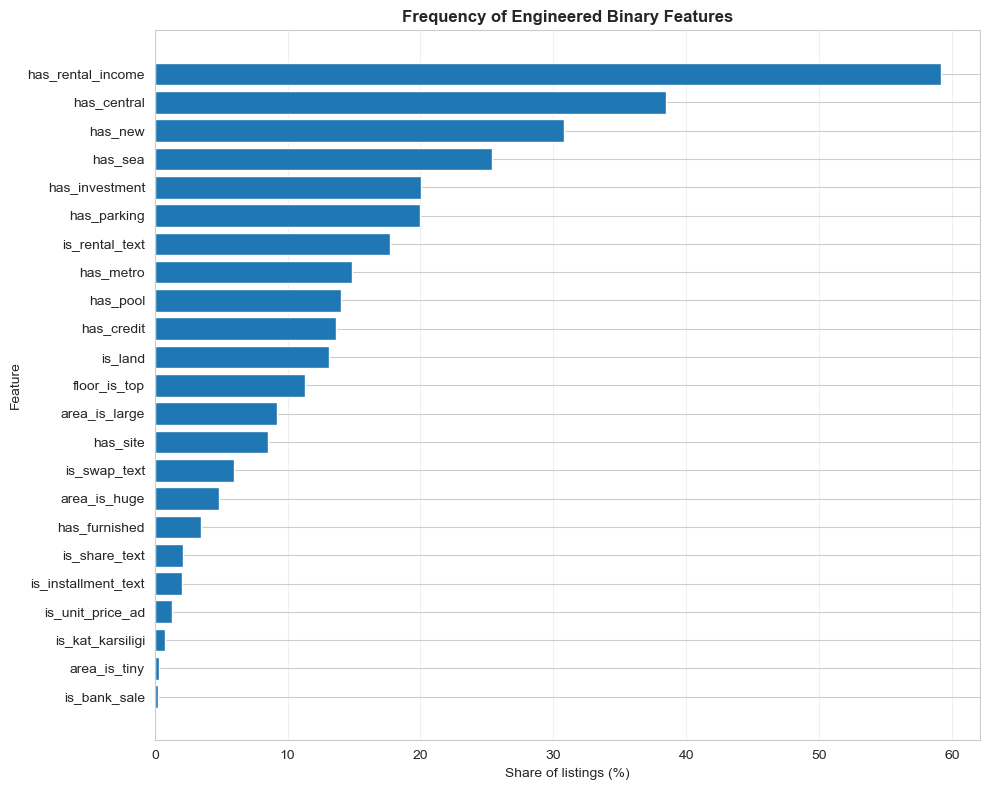

,Share of listings (%)
is_bank_sale,0.21
area_is_tiny,0.32
is_kat_karsiligi,0.76
is_unit_price_ad,1.30
is_installment_text,2.04
is_share_text,2.16
has_furnished,3.47
area_is_huge,4.85
is_swap_text,5.99
has_site,8.52


In [ ]:
# Feature Engineering Visual: Engineered binary feature rates

binary_feature_candidates = [
    "is_land", "has_rental_income",
    "has_metro", "has_sea", "has_parking", "has_pool", "has_site",
    "has_furnished", "has_new", "has_investment", "has_credit", "has_central",
    "is_unit_price_ad", "is_rental_text", "is_installment_text",
    "is_kat_karsiligi", "is_share_text", "is_bank_sale", "is_swap_text",
    "area_is_tiny", "area_is_large", "area_is_huge", "floor_is_top"
]

binary_feature_candidates = [
    col for col in binary_feature_candidates
    if col in train_clean.columns
]

binary_rates = (
    train_clean[binary_feature_candidates]
    .mean()
    .sort_values(ascending=True) * 100
)

plt.figure(figsize=(10, 8))
plt.barh(binary_rates.index, binary_rates.values)
plt.title("Frequency of Engineered Binary Features", fontsize=12, fontweight="bold")
plt.xlabel("Share of listings (%)")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

display(binary_rates.round(2).to_frame("Share of listings (%)"))

In [10]:
# Reduce high-cardinality categorical variables

def fit_category_maps(data, cat_cols):
    """
    Learn which categories to keep from training data.
    Rare categories will later be grouped as 'Other'.
    """
    
    max_levels_by_col = {
        "city": 100,
        "district": 300,
        "quarter": 500,
        "city_district": 500,
        "district_quarter": 800,
        "broker_company": 200,
        "type": 100,
        "room": 80,
        "category": 20,
        "credit_suitability": 20,
        "heating_type": 50,
        "building_type": 30,
        "usage_status": 30
    }
    
    category_maps = {}
    
    for col in cat_cols:
        if col in data.columns:
            counts = data[col].fillna("Unknown").astype(str).value_counts()
            max_levels = max_levels_by_col.get(col, 100)
            keep_values = set(counts.head(max_levels).index)
            category_maps[col] = keep_values
    
    return category_maps


def apply_category_maps(data, cat_cols, category_maps):
    """
    Apply learned category maps to data.
    Categories not seen frequently in training are grouped as 'Other'.
    """
    data = data.copy()
    
    for col in cat_cols:
        if col in data.columns:
            keep_values = category_maps.get(col, set())
            data[col] = data[col].fillna("Unknown").astype(str)
            data[col] = np.where(data[col].isin(keep_values), data[col], "Other")
    
    return data

print("Category mapping functions created.")


Category mapping functions created.


## 7. Train-Validation Split (Only from Training Data)

In [11]:
# Prepare X and y from training data
X = train_clean[all_feature_cols].copy()
y = train_clean["log_price"].copy()

# Stratify by both category and price level
# This gives a validation set closer to the training data distribution.
price_bins = pd.qcut(
    train_clean["log_price"],
    q=10,
    duplicates="drop"
).astype(str)

stratify_values = train_clean["category"].astype(str) + "_" + price_bins

# If a stratum has only one row, fall back to category only
stratum_counts = stratify_values.value_counts()

stratify_values = stratify_values.where(
    stratify_values.map(stratum_counts) >= 2,
    train_clean["category"].astype(str)
)

# Split into train (80%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_values
)

# Learn category maps only from X_train
# This prevents validation category-frequency leakage.
category_maps_val = fit_category_maps(X_train, categorical_cols)

# Apply the same maps to X_train and X_val
X_train = apply_category_maps(X_train, categorical_cols, category_maps_val)
X_val = apply_category_maps(X_val, categorical_cols, category_maps_val)

print("="*60)
print("TRAIN-VALIDATION SPLIT")
print("="*60)
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Training target (y_train): {y_train.shape}")
print(f"Validation target (y_val): {y_val.shape}")

print(f"\nCategory distribution in training set:")
print(X_train["category"].value_counts())

print(f"\nCategory distribution in validation set:")
print(X_val["category"].value_counts())

print("\nUnique values per categorical column after train-fold category reduction:")
for col in categorical_cols:
    print(f"  {col}: train={X_train[col].nunique()}, validation={X_val[col].nunique()}")

TRAIN-VALIDATION SPLIT
Training set: (39924, 65)
Validation set: (9982, 65)
Training target (y_train): (39924,)
Validation target (y_val): (9982,)

Category distribution in training set:
category
Konut     32644
Arsa       5239
Ticari     2021
Turizm       20
Name: count, dtype: int64

Category distribution in validation set:
category
Konut     8162
Arsa      1310
Ticari     506
Turizm       4
Name: count, dtype: int64

Unique values per categorical column after train-fold category reduction:
  city: train=70, validation=67
  district: train=301, validation=282
  quarter: train=501, validation=495
  category: train=4, validation=4
  type: train=63, validation=48
  room: train=49, validation=42
  credit_suitability: train=2, validation=3
  heating_type: train=17, validation=18
  building_type: train=4, validation=4
  usage_status: train=4, validation=5
  broker_company: train=201, validation=201
  city_district: train=439, validation=334
  district_quarter: train=801, validation=774


## 8. Preprocessing Pipeline (ColumnTransformer)

In [ ]:
# Build preprocessing pipeline
# Numerical: impute median, then scale
# Categorical: impute "Unknown", then one-hot encode
# Missing indicators: impute 0, then pass through


try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", onehot)
])

missing_indicator_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
        ("missing", missing_indicator_transformer, missing_indicator_cols)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")
print("Numerical transformer: median imputation + standardization")
print("Categorical transformer: constant imputation ('Unknown') + one-hot encoding")
print("Missing indicators: constant imputation (0) + passthrough")

Preprocessing pipeline created successfully.
Numerical transformer: median imputation + standardization
Categorical transformer: constant imputation ('Unknown') + one-hot encoding
Missing indicators: constant imputation (0) + passthrough


## 9. Evaluation Functions

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, model_name):
    """
    Evaluate model on training and validation sets.
    Predictions are made on log scale, clipped safely, then transformed back to original price scale.
    """

    # Predict on log scale
    y_tr_pred_log = model.predict(X_tr).ravel()
    y_v_pred_log = model.predict(X_v).ravel()

    # Safety: remove possible NaN / infinite values
    y_tr_pred_log = np.nan_to_num(y_tr_pred_log, nan=np.median(y_tr), posinf=np.max(y_tr), neginf=np.min(y_tr))
    y_v_pred_log = np.nan_to_num(y_v_pred_log, nan=np.median(y_tr), posinf=np.max(y_tr), neginf=np.min(y_tr))

    # Clip predictions using TRAIN target range only
    # This prevents exploding prices after expm1()
    log_lower = np.quantile(y_tr, 0.001)
    log_upper = np.quantile(y_tr, 0.999)

    y_tr_pred_log = np.clip(y_tr_pred_log, log_lower, log_upper)
    y_v_pred_log = np.clip(y_v_pred_log, log_lower, log_upper)

    # Transform back to original price scale
    y_tr_real = np.expm1(y_tr)
    y_v_real = np.expm1(y_v)

    y_tr_pred_real = np.maximum(np.expm1(y_tr_pred_log), 1)
    y_v_pred_real = np.maximum(np.expm1(y_v_pred_log), 1)

    # Metrics
    train_mse = mean_squared_error(y_tr_real, y_tr_pred_real)
    val_mse = mean_squared_error(y_v_real, y_v_pred_real)

    train_rmse = np.sqrt(train_mse)
    val_rmse = np.sqrt(val_mse)

    train_mape = mean_absolute_percentage_error(y_tr_real, y_tr_pred_real) * 100
    val_mape = mean_absolute_percentage_error(y_v_real, y_v_pred_real) * 100

    train_median_ape = np.median(np.abs(y_tr_real - y_tr_pred_real) / y_tr_real) * 100
    val_median_ape = np.median(np.abs(y_v_real - y_v_pred_real) / y_v_real) * 100

    return {
        "Model": model_name,
        "Train MSE": train_mse,
        "Val MSE": val_mse,
        "Train RMSE": train_rmse,
        "Val RMSE": val_rmse,
        "Train MAPE (%)": train_mape,
        "Val MAPE (%)": val_mape,
        "Train Median APE (%)": train_median_ape,
        "Val Median APE (%)": val_median_ape
    }

def original_scale_mse(y_true_log, y_pred_log):
    """
    MSE on original price scale.
    """
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log).ravel()

    # Safety against NaN / infinite predictions
    y_pred_log = np.nan_to_num(
        y_pred_log,
        nan=np.median(y_true_log),
        posinf=np.max(y_true_log),
        neginf=np.min(y_true_log)
    )

    # Clip using the current CV fold's true target range
    log_lower = np.quantile(y_true_log, 0.001)
    log_upper = np.quantile(y_true_log, 0.999)
    y_pred_log = np.clip(y_pred_log, log_lower, log_upper)

    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(np.expm1(y_pred_log), 1)

    return mean_squared_error(y_true, y_pred)


def original_scale_mape(y_true_log, y_pred_log):
    """
    MAPE on original price scale.
    """
    y_true_log = np.asarray(y_true_log)
    y_pred_log = np.asarray(y_pred_log).ravel()

    # Safety against NaN / infinite predictions
    y_pred_log = np.nan_to_num(
        y_pred_log,
        nan=np.median(y_true_log),
        posinf=np.max(y_true_log),
        neginf=np.min(y_true_log)
    )

    # Clip using the current CV fold's true target range
    log_lower = np.quantile(y_true_log, 0.001)
    log_upper = np.quantile(y_true_log, 0.999)
    y_pred_log = np.clip(y_pred_log, log_lower, log_upper)

    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(np.expm1(y_pred_log), 1)

    return mean_absolute_percentage_error(y_true, y_pred)

original_scale_mse_scorer = make_scorer(
    original_scale_mse,
    greater_is_better=False
)

original_scale_mape_scorer = make_scorer(
    original_scale_mape,
    greater_is_better=False
)

print("Evaluation functions defined.")

Evaluation functions defined.


## 10. Baseline Models Training

In [ ]:
print("="*60)
print("TRAINING BASELINE MODELS")
print("="*60)

baseline_models = {
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_leaf=10
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=RANDOM_STATE,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    baseline_models["XGBoost"] = xgb.XGBRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1,
        objective="reg:squarederror"
    )

if LIGHTGBM_AVAILABLE:
    baseline_models["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=5,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbose=-1
    )

if CATBOOST_AVAILABLE:
    baseline_models["CatBoost"] = CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False
    )

all_results = []
trained_models = {}

for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    try:
        pipeline.fit(X_train, y_train)
        
        result = evaluate_model(pipeline, X_train, y_train, X_val, y_val, name)
        all_results.append(result)
        trained_models[name] = pipeline
        
        print(f"  Val MSE: {result['Val MSE']:.2f}")
        print(f"  Val MAPE: {result['Val MAPE (%)']:.2f}%")
        
    except Exception as e:
        print(f"  {name} failed.")
        print(f"  Error: {e}")

baseline_results_df = pd.DataFrame(all_results)
print("\n" + "="*60)
print("BASELINE MODELS COMPARISON")
print("="*60)
display(baseline_results_df.sort_values("Val MAPE (%)"))

TRAINING BASELINE MODELS

Training Linear Regression...
  Val MSE: 1333629029967602.75
  Val MAPE: 56.30%

Training Decision Tree...
  Val MSE: 1343896197236089.50
  Val MAPE: 65.76%

Training Random Forest...
  Val MSE: 1338864260687202.75
  Val MAPE: 51.27%

Training Gradient Boosting...
  Val MSE: 1339135938885110.75
  Val MAPE: 56.91%

Training XGBoost...
  Val MSE: 1337776055807949.25
  Val MAPE: 55.84%

Training LightGBM...
  Val MSE: 1333152245988370.50
  Val MAPE: 56.68%

Training CatBoost...
  Val MSE: 1334643217882225.75
  Val MAPE: 56.06%

BASELINE MODELS COMPARISON


,Model,Train MSE,Val MSE,Train RMSE,Val RMSE,Train MAPE (%),Val MAPE (%),Train Median APE (%),Val Median APE (%)
2,Random Forest,3.448973e+14,1.338864e+15,1.857141e+07,3.659049e+07,30.501747,51.266056,17.035390,22.400717
4,XGBoost,3.488464e+14,1.337776e+15,1.867743e+07,3.657562e+07,47.047576,55.837568,26.900824,27.269634
6,CatBoost,3.492192e+14,1.334643e+15,1.868741e+07,3.653277e+07,48.877935,56.064602,26.486611,26.441037
0,Linear Regression,3.454703e+14,1.333629e+15,1.858683e+07,3.651889e+07,42.788535,56.303209,21.635281,22.959701
5,LightGBM,3.302361e+14,1.333152e+15,1.817240e+07,3.651236e+07,27.819515,56.680360,17.079181,19.565183
3,Gradient Boosting,3.512506e+14,1.339136e+15,1.874168e+07,3.659421e+07,51.079748,56.912123,28.872325,28.658889
1,Decision Tree,3.495797e+14,1.343896e+15,1.869705e+07,3.665919e+07,54.574986,65.762008,29.123618,31.080208


## 11. Neural Network: Detailed Training and Analysis

In [15]:
print("="*60)
print("NEURAL NETWORK MODEL")
print("="*60)

# Create NN with early stopping
nn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=64,
        learning_rate="adaptive",
        learning_rate_init=0.0005,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE,
        verbose=False
    ))
])

print("\nNeural Network Architecture:")
print("  Hidden layers: (128, 64)")
print("  Activation: ReLU")
print("  Solver: Adam optimizer")
print("  Learning rate: 0.0005")
print("  Batch size: 64")
print("  L2 regularization (alpha): 0.001")
print("  Early stopping: Yes")
print("  Internal validation fraction: 0.15")
print("\nFitting Neural Network...\n")

nn_model.fit(X_train, y_train)

print("\nNeural Network training completed.")

NEURAL NETWORK MODEL

Neural Network Architecture:
  Hidden layers: (128, 64)
  Activation: ReLU
  Solver: Adam optimizer
  Learning rate: 0.0005
  Batch size: 64
  L2 regularization (alpha): 0.001
  Early stopping: Yes
  Internal validation fraction: 0.15

Fitting Neural Network...


Neural Network training completed.


In [16]:
# Inspect Neural Network details
nn_core = nn_model.named_steps["model"]

print("\nNeural Network Training Details:")
print(f"  Number of iterations: {nn_core.n_iter_}")
print(f"  Final training loss: {nn_core.loss_:.6f}")
print(f"  Number of layers: {nn_core.n_layers_}")
print(f"  Number of outputs: {nn_core.n_outputs_}")
print(f"  Output activation: {nn_core.out_activation_}")

if hasattr(nn_core, "best_validation_score_"):
    print(f"  Best internal validation score (R2): {nn_core.best_validation_score_:.6f}")

# Evaluate Neural Network
nn_result = evaluate_model(
    nn_model,
    X_train,
    y_train,
    X_val,
    y_val,
    "Neural Network"
)

# Remove previous Neural Network result if this cell is rerun
all_results = [
    result for result in all_results
    if result["Model"] != "Neural Network"
]

# Add updated result
all_results.append(nn_result)
trained_models["Neural Network"] = nn_model

print("\nNeural Network Performance:")
print(f"  Train MSE: {nn_result['Train MSE']:.2f}")
print(f"  Val MSE: {nn_result['Val MSE']:.2f}")
print(f"  Train MAPE: {nn_result['Train MAPE (%)']:.2f}%")
print(f"  Val MAPE: {nn_result['Val MAPE (%)']:.2f}%")
print(f"  Train Median APE: {nn_result['Train Median APE (%)']:.2f}%")
print(f"  Val Median APE: {nn_result['Val Median APE (%)']:.2f}%")


Neural Network Training Details:
  Number of iterations: 41
  Final training loss: 0.041176
  Number of layers: 4
  Number of outputs: 1
  Output activation: identity
  Best internal validation score (R2): 0.796562

Neural Network Performance:
  Train MSE: 340140412097997.88
  Val MSE: 1335092196714348.75
  Train MAPE: 35.13%
  Val MAPE: 59.96%
  Train Median APE: 20.03%
  Val Median APE: 23.91%


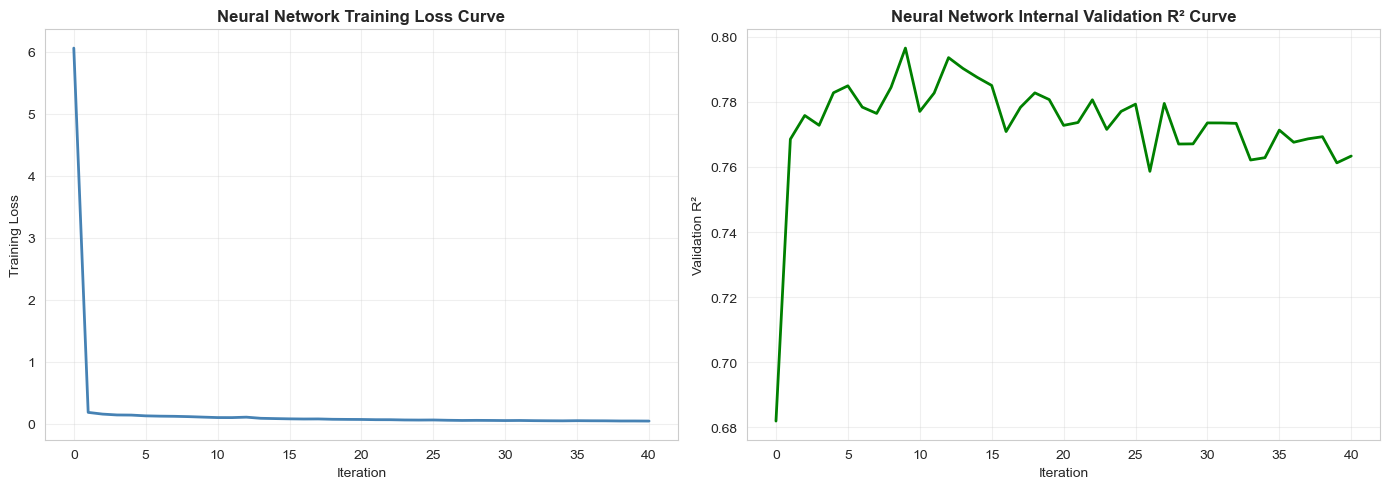

In [17]:
# Plot Neural Network training loss and internal validation score curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curve
if hasattr(nn_core, "loss_curve_"):
    axes[0].plot(nn_core.loss_curve_, linewidth=2, color="steelblue")
    axes[0].set_title("Neural Network Training Loss Curve", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("Training Loss")
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(
        0.5, 0.5,
        "Training loss curve not available",
        ha="center",
        va="center",
        transform=axes[0].transAxes
    )
    axes[0].set_xticks([])
    axes[0].set_yticks([])

# Internal validation R2 curve
if hasattr(nn_core, "validation_scores_"):
    axes[1].plot(nn_core.validation_scores_, linewidth=2, color="green")
    axes[1].set_title("Neural Network Internal Validation R² Curve", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Validation R²")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "Internal validation scores not available",
        ha="center",
        va="center",
        transform=axes[1].transAxes
    )
    axes[1].set_xticks([])
    axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## 12. Hyperparameter Tuning (GridSearchCV)

In [18]:
print("="*60)
print("HYPERPARAMETER TUNING: DECISION TREE")
print("="*60)

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
])

dt_param_grid = {
    "model__max_depth": [8, 12, 16, 20],
    "model__min_samples_split": [10, 20, 30],
    "model__min_samples_leaf": [5, 10, 15, 20]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring=original_scale_mse_scorer,
    cv=3,
    n_jobs=-1,
    verbose=0
)

print("Fitting GridSearchCV for Decision Tree...")
dt_grid.fit(X_train, y_train)

print(f"\nBest Decision Tree Parameters:")
for param, value in dt_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MSE: {-dt_grid.best_score_:.2f}")

tuned_dt_result = evaluate_model(
    dt_grid.best_estimator_,
    X_train,
    y_train,
    X_val,
    y_val,
    "Tuned Decision Tree"
)

# Remove previous result if this cell is rerun
all_results = [
    result for result in all_results
    if result["Model"] != "Tuned Decision Tree"
]

all_results.append(tuned_dt_result)
trained_models["Tuned Decision Tree"] = dt_grid.best_estimator_

print(f"\nTuned Decision Tree Performance:")
print(f"  Val MSE: {tuned_dt_result['Val MSE']:.2f}")
print(f"  Val MAPE: {tuned_dt_result['Val MAPE (%)']:.2f}%")

HYPERPARAMETER TUNING: DECISION TREE
Fitting GridSearchCV for Decision Tree...

Best Decision Tree Parameters:
  model__max_depth: 20
  model__min_samples_leaf: 5
  model__min_samples_split: 20

Best CV MSE: 353862626500297.88

Tuned Decision Tree Performance:
  Val MSE: 1339684453257608.25
  Val MAPE: 62.57%


In [19]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING: RANDOM FOREST")
print("="*60)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

# Smaller grid to reduce runtime
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [15, 20],
    "model__min_samples_leaf": [3, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring=original_scale_mse_scorer,
    cv=3,
    n_jobs=-1,
    verbose=0
)

print("Fitting GridSearchCV for Random Forest...")
rf_grid.fit(X_train, y_train)

print(f"\nBest Random Forest Parameters:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MSE: {-rf_grid.best_score_:.2f}")

tuned_rf_result = evaluate_model(
    rf_grid.best_estimator_,
    X_train,
    y_train,
    X_val,
    y_val,
    "Tuned Random Forest"
)

# Remove previous result if this cell is rerun
all_results = [
    result for result in all_results
    if result["Model"] != "Tuned Random Forest"
]

all_results.append(tuned_rf_result)
trained_models["Tuned Random Forest"] = rf_grid.best_estimator_

print(f"\nTuned Random Forest Performance:")
print(f"  Val MSE: {tuned_rf_result['Val MSE']:.2f}")
print(f"  Val MAPE: {tuned_rf_result['Val MAPE (%)']:.2f}%")
print(f"  Val Median APE: {tuned_rf_result['Val Median APE (%)']:.2f}%")


HYPERPARAMETER TUNING: RANDOM FOREST
Fitting GridSearchCV for Random Forest...

Best Random Forest Parameters:
  model__max_depth: 20
  model__max_features: sqrt
  model__min_samples_leaf: 3
  model__n_estimators: 100

Best CV MSE: 365619491462631.81

Tuned Random Forest Performance:
  Val MSE: 1351405832811303.75
  Val MAPE: 56.32%
  Val Median APE: 31.95%


In [20]:
print("\n" + "="*60)
print("HYPERPARAMETER TUNING: GRADIENT BOOSTING")
print("="*60)

gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8],
    "model__min_samples_leaf": [5, 10]
}

gb_grid = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring=original_scale_mse_scorer,
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Fitting GridSearchCV for Gradient Boosting...")
gb_grid.fit(X_train, y_train)

print(f"\nBest Gradient Boosting Parameters:")
for param, value in gb_grid.best_params_.items():
    print(f"  {param}: {value}")

tuned_gb_result = evaluate_model(
    gb_grid.best_estimator_, X_train, y_train, X_val, y_val,
    "Tuned Gradient Boosting"
)

all_results = [
    result for result in all_results
    if result["Model"] != "Tuned Gradient Boosting"
]

all_results.append(tuned_gb_result)
trained_models["Tuned Gradient Boosting"] = gb_grid.best_estimator_

print(f"\nTuned Gradient Boosting Performance:")
print(f"  Val MSE: {tuned_gb_result['Val MSE']:.2f}")
print(f"  Val MAPE: {tuned_gb_result['Val MAPE (%)']:.2f}%")


HYPERPARAMETER TUNING: GRADIENT BOOSTING
Fitting GridSearchCV for Gradient Boosting...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Gradient Boosting Parameters:
  model__learning_rate: 0.1
  model__max_depth: 4
  model__min_samples_leaf: 10
  model__n_estimators: 150
  model__subsample: 0.8

Tuned Gradient Boosting Performance:
  Val MSE: 1338114665362276.75
  Val MAPE: 57.16%


In [21]:
print("="*60)
print("HYPERPARAMETER TUNING: NEURAL NETWORK")
print("="*60)

nn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", MLPRegressor(
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
        max_iter=500,
        verbose=False
    ))
])

nn_param_grid = {
    "model__hidden_layer_sizes": [(64, 32), (128, 64)],
    "model__alpha": [0.001, 0.01],
    "model__learning_rate_init": [0.0003, 0.0005],
    "model__batch_size": [64]
}

nn_grid = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=nn_param_grid,
    scoring=original_scale_mse_scorer,
    cv=3,
    n_jobs=1,
    verbose=2
)

print("Fitting GridSearchCV for Neural Network...")
nn_grid.fit(X_train, y_train)

print(f"\nBest Neural Network Parameters:")
for param, value in nn_grid.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MSE: {-nn_grid.best_score_:.2f}")

tuned_nn_result = evaluate_model(
    nn_grid.best_estimator_,
    X_train,
    y_train,
    X_val,
    y_val,
    "Tuned Neural Network"
)

# Remove previous result if this cell is rerun
all_results = [
    result for result in all_results
    if result["Model"] != "Tuned Neural Network"
]

all_results.append(tuned_nn_result)
trained_models["Tuned Neural Network"] = nn_grid.best_estimator_

print(f"\nTuned Neural Network Performance:")
print(f"  Val MSE: {tuned_nn_result['Val MSE']:.2f}")
print(f"  Val MAPE: {tuned_nn_result['Val MAPE (%)']:.2f}%")
print(f"  Val Median APE: {tuned_nn_result['Val Median APE (%)']:.2f}%")

HYPERPARAMETER TUNING: NEURAL NETWORK
Fitting GridSearchCV for Neural Network...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0003; total time= 1.5min
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0003; total time= 1.9min
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0003; total time= 1.4min
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time= 1.5min
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time= 1.4min
[CV] END model__alpha=0.001, model__batch_size=64, model__hidden_layer_sizes=(64, 32), model__learning_rate_init=0.0005; total time= 1.2min
[CV] END model__alp

In [22]:
print("="*60)
print("HYPERPARAMETER TUNING: LIGHTGBM")
print("="*60)

if LIGHTGBM_AVAILABLE:
    lgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", lgb.LGBMRegressor(
            random_state=RANDOM_STATE,
            verbose=-1,
            subsample_freq=5
        ))
    ])

    lgb_param_grid = {
        "model__n_estimators": [300, 500],
        "model__num_leaves": [31, 63],
        "model__learning_rate": [0.03, 0.05],
        "model__min_child_samples": [20, 50],
        "model__reg_lambda": [1.0, 5.0],
        "model__colsample_bytree": [0.7, 0.8]
    }

    lgb_grid = GridSearchCV(
        estimator=lgb_pipeline,
        param_grid=lgb_param_grid,
        scoring=original_scale_mse_scorer,
        cv=3,
        n_jobs=-1,
        verbose=0
    )

    print("Fitting GridSearchCV for LightGBM...")
    lgb_grid.fit(X_train, y_train)

    print(f"\nBest LightGBM Parameters:")
    for param, value in lgb_grid.best_params_.items():
        print(f"  {param}: {value}")

    print(f"\nBest CV MSE: {-lgb_grid.best_score_:.2f}")

    tuned_lgb_result = evaluate_model(
        lgb_grid.best_estimator_,
        X_train,
        y_train,
        X_val,
        y_val,
        "Tuned LightGBM"
    )

    all_results = [r for r in all_results if r["Model"] != "Tuned LightGBM"]
    all_results.append(tuned_lgb_result)
    trained_models["Tuned LightGBM"] = lgb_grid.best_estimator_

    print(f"\nTuned LightGBM Performance:")
    print(f"  Val MSE:        {tuned_lgb_result['Val MSE']:.2f}")
    print(f"  Val MAPE:       {tuned_lgb_result['Val MAPE (%)']:.2f}%")
    print(f"  Val Median APE: {tuned_lgb_result['Val Median APE (%)']:.2f}%")

else:
    print("LightGBM not available — skipping tuning.")


HYPERPARAMETER TUNING: LIGHTGBM
Fitting GridSearchCV for LightGBM...

Best LightGBM Parameters:
  model__colsample_bytree: 0.7
  model__learning_rate: 0.05
  model__min_child_samples: 20
  model__n_estimators: 500
  model__num_leaves: 63
  model__reg_lambda: 1.0

Best CV MSE: 346165153697199.50

Tuned LightGBM Performance:
  Val MSE:        1332573467010529.00
  Val MAPE:       54.90%
  Val Median APE: 19.44%


## 13. Final Model Comparison and Selection

FINAL MODEL COMPARISON (Ranked by Average MSE and MAPE Rank)


,Model,Train MSE,Val MSE,Train RMSE,Val RMSE,Train MAPE (%),Val MAPE (%),Train Median APE (%),Val Median APE (%),MSE Rank,MAPE Rank,Median APE Rank,Avg Rank
0,Tuned LightGBM,3.344126e+14,1.332573e+15,1.828695e+07,3.650443e+07,27.953020,54.899985,16.702347,19.436267,2.0,3.0,1.0,2.000000
1,Tuned Neural Network,3.392453e+14,1.331560e+15,1.841861e+07,3.649055e+07,35.327458,53.867199,19.507126,23.462671,1.0,2.0,5.0,2.666667
2,Random Forest,3.448973e+14,1.338864e+15,1.857141e+07,3.659049e+07,30.501747,51.266056,17.035390,22.400717,9.0,1.0,3.0,4.333333
3,LightGBM,3.302361e+14,1.333152e+15,1.817240e+07,3.651236e+07,27.819515,56.680360,17.079181,19.565183,3.0,8.0,2.0,4.333333
4,Linear Regression,3.454703e+14,1.333629e+15,1.858683e+07,3.651889e+07,42.788535,56.303209,21.635281,22.959701,4.0,6.0,4.0,4.666667
5,CatBoost,3.492192e+14,1.334643e+15,1.868741e+07,3.653277e+07,48.877935,56.064602,26.486611,26.441037,5.0,5.0,8.0,6.000000
6,XGBoost,3.488464e+14,1.337776e+15,1.867743e+07,3.657562e+07,47.047576,55.837568,26.900824,27.269634,7.0,4.0,10.0,7.000000
7,Neural Network,3.401404e+14,1.335092e+15,1.844290e+07,3.653891e+07,35.125266,59.957809,20.029964,23.906937,6.0,11.0,6.0,7.666667
8,Tuned Gradient Boosting,3.471705e+14,1.338115e+15,1.863251e+07,3.658025e+07,47.690388,57.162810,26.386359,26.347498,8.0,10.0,7.0,8.333333
9,Gradient Boosting,3.512506e+14,1.339136e+15,1.874168e+07,3.659421e+07,51.079748,56.912123,28.872325,28.658889,10.0,9.0,11.0,10.000000


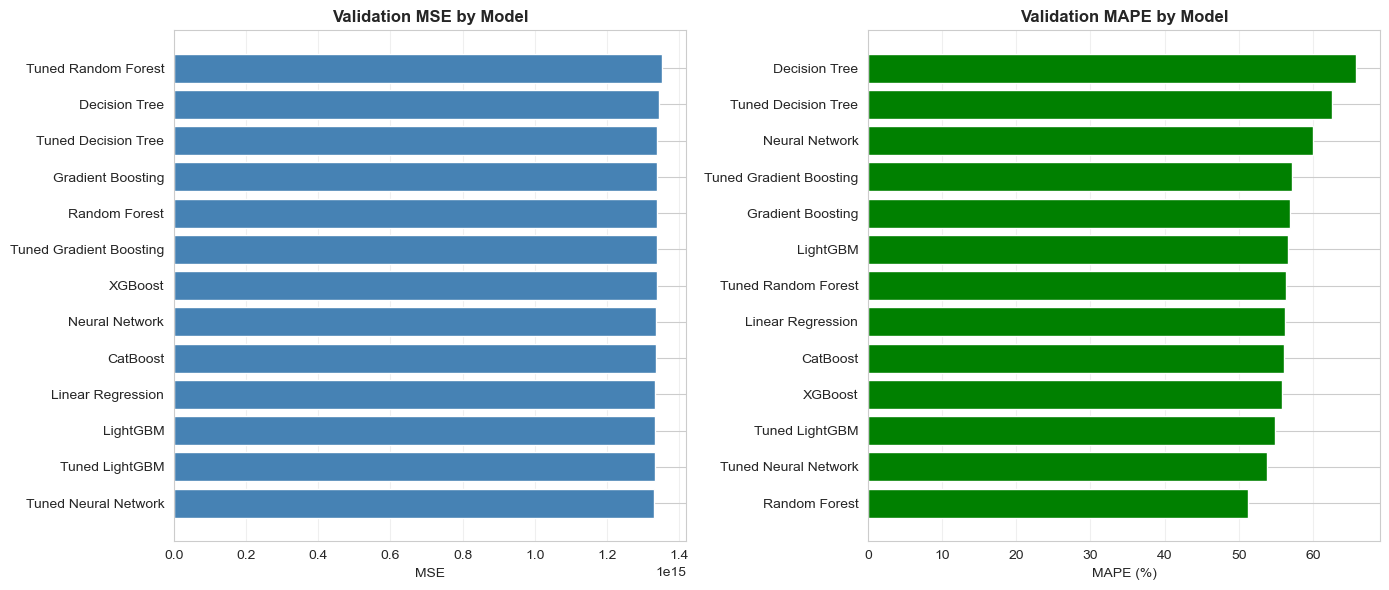


BEST MODEL: Tuned LightGBM
Val MSE: 1332573467010529.00
Val MAPE: 54.90%
Avg Rank: 2.00


In [23]:
# Compile all results
final_results_df = pd.DataFrame(all_results)

# Remove duplicate model rows if any cell was rerun
final_results_df = final_results_df.drop_duplicates(
    subset=["Model"],
    keep="last"
).reset_index(drop=True)

# Rank models by MSE and Median APE (more robust to extreme outliers than mean MAPE)
final_results_df["MSE Rank"] = final_results_df["Val MSE"].rank(method="min")
final_results_df["MAPE Rank"] = final_results_df["Val MAPE (%)"].rank(method="min")
final_results_df["Median APE Rank"] = final_results_df["Val Median APE (%)"].rank(method="min")

# Avg rank: equal weight MSE + Median APE + MAPE
# Median APE is more robust to extreme low-price outliers than mean MAPE
final_results_df["Avg Rank"] = (
    final_results_df["MSE Rank"] +
    final_results_df["Median APE Rank"] +
    final_results_df["MAPE Rank"]
) / 3

# Sort by average rank
final_results_df = final_results_df.sort_values("Avg Rank").reset_index(drop=True)

# Select best global model
best_global_model_name = final_results_df.iloc[0]["Model"]
best_global_model = trained_models[best_global_model_name]

print("="*80)
print("FINAL MODEL COMPARISON (Ranked by Average MSE and MAPE Rank)")
print("="*80)
display(final_results_df)

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MSE comparison
sorted_by_mse = final_results_df.sort_values("Val MSE")
axes[0].barh(sorted_by_mse["Model"], sorted_by_mse["Val MSE"], color="steelblue")
axes[0].set_title("Validation MSE by Model", fontsize=12, fontweight="bold")
axes[0].set_xlabel("MSE")
axes[0].grid(True, alpha=0.3, axis="x")

# MAPE comparison
sorted_by_mape = final_results_df.sort_values("Val MAPE (%)")
axes[1].barh(sorted_by_mape["Model"], sorted_by_mape["Val MAPE (%)"], color="green")
axes[1].set_title("Validation MAPE by Model", fontsize=12, fontweight="bold")
axes[1].set_xlabel("MAPE (%)")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"BEST MODEL: {best_global_model_name}")
print("="*60)
print(f"Val MSE: {final_results_df.iloc[0]['Val MSE']:.2f}")
print(f"Val MAPE: {final_results_df.iloc[0]['Val MAPE (%)']:.2f}%")
print(f"Avg Rank: {final_results_df.iloc[0]['Avg Rank']:.2f}")

## 14. Category-Specific Models (To Improve Weak Categories)

In [24]:
print("="*60)
print("CATEGORY-SPECIFIC MODEL TRAINING")
print("="*60)

# Select the best global model from the final comparison table
best_global_model_name = final_results_df.iloc[0]["Model"]
best_global_pipeline = trained_models[best_global_model_name]

print(f"\nGlobal model: {best_global_model_name}")

# Check category distribution
cat_counts_train = X_train["category"].value_counts()
cat_counts_val = X_val["category"].value_counts()

print("\nCategory distribution in training set:")
display(cat_counts_train)

print("\nCategory distribution in validation set:")
display(cat_counts_val)

# Minimum sample requirements for reliable category-specific models
min_train_samples_for_category = 100
min_val_samples_for_category = 20

categories_to_train = []

for cat in cat_counts_train.index:
    train_count = cat_counts_train.get(cat, 0)
    val_count = cat_counts_val.get(cat, 0)
    
    if train_count >= min_train_samples_for_category and val_count >= min_val_samples_for_category:
        categories_to_train.append(cat)

print(f"\nCategories selected for separate model testing:")
print(categories_to_train)

category_models = {}
category_results = {}
approved_categories = []

for cat in categories_to_train:
    print(f"\nTesting category-specific model for: {cat}")
    
    cat_mask_train = X_train["category"] == cat
    cat_mask_val = X_val["category"] == cat
    
    X_train_cat = X_train[cat_mask_train]
    y_train_cat = y_train[cat_mask_train]
    X_val_cat = X_val[cat_mask_val]
    y_val_cat = y_val[cat_mask_val]
    
    # 1. Evaluate global model on this category
    global_cat_result = evaluate_model(
        best_global_pipeline,
        X_train_cat,
        y_train_cat,
        X_val_cat,
        y_val_cat,
        f"{cat} - Global Model"
    )
    
    # 2. Train category-specific model using same model structure and parameters
    cat_pipeline = clone(best_global_pipeline)
    cat_pipeline.fit(X_train_cat, y_train_cat)
    
    cat_result = evaluate_model(
        cat_pipeline,
        X_train_cat,
        y_train_cat,
        X_val_cat,
        y_val_cat,
        f"{cat} - Category Model"
    )
    
    category_results[cat] = {
        "Category": cat,
        "Train Count": len(X_train_cat),
        "Validation Count": len(X_val_cat),
        "Global Val MSE": global_cat_result["Val MSE"],
        "Global Val MAPE (%)": global_cat_result["Val MAPE (%)"],
        "Category Val MSE": cat_result["Val MSE"],
        "Category Val MAPE (%)": cat_result["Val MAPE (%)"],
        "MSE Improvement (%)": (
            (global_cat_result["Val MSE"] - cat_result["Val MSE"])
            / global_cat_result["Val MSE"]
        ) * 100,
        "MAPE Improvement (%)": (
            (global_cat_result["Val MAPE (%)"] - cat_result["Val MAPE (%)"])
            / global_cat_result["Val MAPE (%)"]
        ) * 100
    }
    
    print(f"  Global model MSE:    {global_cat_result['Val MSE']:.2f}")
    print(f"  Category model MSE:  {cat_result['Val MSE']:.2f}")
    print(f"  Global model MAPE:   {global_cat_result['Val MAPE (%)']:.2f}%")
    print(f"  Category model MAPE: {cat_result['Val MAPE (%)']:.2f}%")
    
    # 3. Approve category model only if it improves MAPE and does not hurt MSE too much
    improves_mape = cat_result["Val MAPE (%)"] < global_cat_result["Val MAPE (%)"]
    mse_not_much_worse = cat_result["Val MSE"] <= 1.10 * global_cat_result["Val MSE"]
    
    if improves_mape and mse_not_much_worse:
        category_models[cat] = cat_pipeline
        approved_categories.append(cat)
        print(f"  APPROVED: using separate {cat} model.")
    else:
        print(f"  NOT approved: fallback to global model for {cat}.")

print("\n" + "="*60)
print("CATEGORY MODEL DECISION SUMMARY")
print("="*60)

category_results_df = pd.DataFrame(list(category_results.values()))

if len(category_results_df) > 0:
    display(category_results_df.sort_values("MAPE Improvement (%)", ascending=False))
else:
    print("No category-specific models were tested due to sample size limits.")

print("\nApproved categories:")
print(approved_categories)

CATEGORY-SPECIFIC MODEL TRAINING

Global model: Tuned LightGBM

Category distribution in training set:


category
Konut     32644
Arsa       5239
Ticari     2021
Turizm       20
Name: count, dtype: int64


Category distribution in validation set:


category
Konut     8162
Arsa      1310
Ticari     506
Turizm       4
Name: count, dtype: int64


Categories selected for separate model testing:
['Konut', 'Arsa', 'Ticari']

Testing category-specific model for: Konut
  Global model MSE:    25357134015660.48
  Category model MSE:  23016278100402.95
  Global model MAPE:   25.45%
  Category model MAPE: 24.59%
  APPROVED: using separate Konut model.

Testing category-specific model for: Arsa
  Global model MSE:    9991056252533104.00
  Category model MSE:  9972989824174412.00
  Global model MAPE:   243.34%
  Category model MAPE: 192.20%
  APPROVED: using separate Arsa model.

Testing category-specific model for: Ticari
  Global model MSE:    35789624040961.02
  Category model MSE:  38613321327313.39
  Global model MAPE:   72.82%
  Category model MAPE: 80.70%
  NOT approved: fallback to global model for Ticari.

CATEGORY MODEL DECISION SUMMARY


,Category,Train Count,Validation Count,Global Val MSE,Global Val MAPE (%),Category Val MSE,Category Val MAPE (%),MSE Improvement (%),MAPE Improvement (%)
1,Arsa,5239,1310,9.991056e+15,243.344630,9.972990e+15,192.202502,0.180826,21.016337
0,Konut,32644,8162,2.535713e+13,25.450783,2.301628e+13,24.592303,9.231548,3.373098
2,Ticari,2021,506,3.578962e+13,72.815434,3.861332e+13,80.700148,-7.889709,-10.828356



Approved categories:
['Konut', 'Arsa']


## 15. Retrain Final Model on Full Training Data

In [25]:
print("="*60)
print("RETRAINING FINAL MODEL ON FULL TRAINING DATA")
print("="*60)

# Prepare full training data
X_full_raw = train_clean[all_feature_cols].copy()
y_full = train_clean["log_price"].copy()

# Fit category maps again using the full training data only.
# This is allowed after model selection because the test data is not used.
category_maps = fit_category_maps(X_full_raw, categorical_cols)

# Apply full-training category maps
X_full = apply_category_maps(X_full_raw, categorical_cols, category_maps)

print(f"\nFull training feature shape: {X_full.shape}")
print(f"Full training target shape: {y_full.shape}")

print("\nUnique values per categorical column after full-training category reduction:")
for col in categorical_cols:
    print(f"  {col}: {X_full[col].nunique()} unique values")

# Select best global model
best_global_model_name = final_results_df.iloc[0]["Model"]

if "best_global_pipeline" not in globals():
    best_global_pipeline = trained_models[best_global_model_name]

print(f"\nBest global model selected: {best_global_model_name}")

# Retrain best global model on all training data
final_global_model = clone(best_global_pipeline)
final_global_model.fit(X_full, y_full)

print(f"\nFinal global model retrained on {len(X_full)} samples.")

# Retrain only approved category-specific models on full training data
final_category_models = {}

if "approved_categories" not in globals():
    approved_categories = []

print("\nRetraining approved category-specific models...")

for cat in approved_categories:
    cat_mask = X_full["category"] == cat
    
    X_cat = X_full[cat_mask]
    y_cat = y_full[cat_mask]
    
    if len(X_cat) == 0:
        print(f"  Skipped {cat}: no samples found.")
        continue
    
    try:
        cat_model = clone(best_global_pipeline)
        cat_model.fit(X_cat, y_cat)
        final_category_models[cat] = cat_model
        
        print(f"  Retrained approved {cat} model on {len(X_cat)} samples.")
    
    except Exception as e:
        print(f"  Failed to retrain {cat} model.")
        print(f"  Error: {e}")

print("\n" + "="*60)
print("FINAL RETRAINING SUMMARY")
print("="*60)
print(f"Final global model: {best_global_model_name}")
print(f"Global model training samples: {len(X_full)}")
print(f"Final category models: {list(final_category_models.keys())}")

RETRAINING FINAL MODEL ON FULL TRAINING DATA

Full training feature shape: (49906, 65)
Full training target shape: (49906,)

Unique values per categorical column after full-training category reduction:
  city: 70 unique values
  district: 301 unique values
  quarter: 501 unique values
  category: 4 unique values
  type: 64 unique values
  room: 49 unique values
  credit_suitability: 3 unique values
  heating_type: 18 unique values
  building_type: 4 unique values
  usage_status: 5 unique values
  broker_company: 201 unique values
  city_district: 452 unique values
  district_quarter: 801 unique values

Best global model selected: Tuned LightGBM

Final global model retrained on 49906 samples.

Retraining approved category-specific models...
  Retrained approved Konut model on 40806 samples.
  Retrained approved Arsa model on 6549 samples.

FINAL RETRAINING SUMMARY
Final global model: Tuned LightGBM
Global model training samples: 49906
Final category models: ['Konut', 'Arsa']


## 16. Prepare Test Data and Make Predictions

In [26]:
print("="*60) 
print("PREPARING TEST DATA")
print("="*60)

# Clean test data using the same rule-based cleaning function
# Important: is_train=False prevents removing test rows based on target/outlier rules
test_clean = clean_real_estate_data(test_df, is_train=False)

print(f"\nOriginal test data shape: {test_df.shape}")
print(f"Cleaned test data shape: {test_clean.shape}")

# Safety check: test row count should stay the same
assert test_clean.shape[0] == test_df.shape[0], "Test row count changed during cleaning!"

# Check missing feature columns before adding them
missing_test_features = [col for col in all_feature_cols if col not in test_clean.columns]

print("\nMissing feature columns in test data:")
print(missing_test_features)

# Ensure all feature columns exist
for col in all_feature_cols:
    if col not in test_clean.columns:
        test_clean[col] = np.nan

# Apply learned category maps to test data
test_clean = apply_category_maps(test_clean, categorical_cols, category_maps)

# Final test feature matrix
X_test = test_clean[all_feature_cols]

print(f"\nTest feature matrix shape: {X_test.shape}")

print(f"\nTest category distribution:")
display(test_clean["category"].value_counts(dropna=False))

PREPARING TEST DATA

Original test data shape: (50000, 29)
Cleaned test data shape: (50000, 70)

Missing feature columns in test data:
[]

Test feature matrix shape: (50000, 65)

Test category distribution:


category
Konut     33507
Arsa      12292
Ticari     4114
Turizm       87
Name: count, dtype: int64

In [27]:
print("="*60)
print("MAKING TEST PREDICTIONS")
print("="*60)

# Make predictions using global model
test_predictions_log = final_global_model.predict(X_test).ravel()

assert len(test_predictions_log) == len(X_test), "Prediction length does not match test data length!"

# Safety: remove NaN / infinite values
test_predictions_log = np.nan_to_num(
    test_predictions_log,
    nan=np.median(y_full),
    posinf=np.max(y_full),
    neginf=np.min(y_full)
)

# Override with approved category-specific predictions where available
for cat, cat_model in final_category_models.items():
    cat_mask = (test_clean["category"] == cat).values
    
    if cat_mask.sum() > 0:
        X_test_cat = X_test.loc[cat_mask]
        cat_pred_log = cat_model.predict(X_test_cat).ravel()
        
        cat_pred_log = np.nan_to_num(
            cat_pred_log,
            nan=np.median(y_full),
            posinf=np.max(y_full),
            neginf=np.min(y_full)
        )
        
        test_predictions_log[cat_mask] = cat_pred_log
        print(f"Using approved {cat} model for {cat_mask.sum()} test samples")

# Clip log predictions using full training target range only
log_lower = np.quantile(y_full, 0.001)
log_upper = np.quantile(y_full, 0.999)

test_predictions_log = np.clip(test_predictions_log, log_lower, log_upper)

# Transform predictions back to original price scale
test_predictions_price = np.maximum(np.expm1(test_predictions_log), 1)

# Category-based clipping to avoid impossible predictions
# These limits are based only on training data, not test data.
category_price_limits = train_clean.groupby("category")["price"].quantile(0.999).to_dict()
global_upper_limit = train_clean["price"].quantile(0.999)

for cat in test_clean["category"].unique():
    cat_mask = (test_clean["category"] == cat).values
    upper_limit = category_price_limits.get(cat, global_upper_limit)
    
    test_predictions_price[cat_mask] = np.minimum(
        test_predictions_price[cat_mask],
        upper_limit
    )

# Final lower bound
test_predictions_price = np.maximum(test_predictions_price, 1)

assert len(test_predictions_price) == len(test_clean), "Final prediction length does not match test data length!"
assert np.all(np.isfinite(test_predictions_price)), "Predictions contain NaN or infinite values!"

print(f"\nTest predictions shape: {test_predictions_price.shape}")
print("Prediction statistics:")
print(f"  Min: {test_predictions_price.min():.2f}")
print(f"  Mean: {test_predictions_price.mean():.2f}")
print(f"  Median: {np.median(test_predictions_price):.2f}")
print(f"  Max: {test_predictions_price.max():.2f}")

MAKING TEST PREDICTIONS
Using approved Konut model for 33507 test samples
Using approved Arsa model for 12292 test samples

Test predictions shape: (50000,)
Prediction statistics:
  Min: 18000.00
  Mean: 978344.10
  Median: 388945.84
  Max: 108188426.34


## 17. Test Set Evaluation and Category-Based Analysis

In [28]:
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

if "price" in test_clean.columns:
    y_test = test_clean["price"]
    
    # Filter to valid values
    valid_mask = y_test.notna() & (y_test > 0) & (test_predictions_price > 0)
    
    y_test_valid = y_test[valid_mask].values
    y_pred_valid = test_predictions_price[valid_mask.values]
    
    # Calculate metrics
    test_mse = mean_squared_error(y_test_valid, y_pred_valid)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test_valid, y_pred_valid)
    test_mape = mean_absolute_percentage_error(y_test_valid, y_pred_valid) * 100
    test_median_ape = np.median(
        np.abs(y_test_valid - y_pred_valid) / y_test_valid
    ) * 100
    
    print(f"\nTest Metrics ({valid_mask.sum()} valid predictions):")
    print(f"  MSE: {test_mse:.2f}")
    print(f"  RMSE: {test_rmse:.2f}")
    print(f"  MAE: {test_mae:.2f}")
    print(f"  MAPE: {test_mape:.2f}%")
    print(f"  Median APE: {test_median_ape:.2f}%")
    
    metrics_df = pd.DataFrame({
        "Metric": ["MSE", "RMSE", "MAE", "MAPE (%)", "Median APE (%)"],
        "Value": [test_mse, test_rmse, test_mae, test_mape, test_median_ape]
    })
    
    display(metrics_df)

else:
    print("\nNote: Test dataset does not contain price information.")
    print("Predictions will be saved without validation metrics.")

TEST SET EVALUATION

Test Metrics (49999 valid predictions):
  MSE: 287268963993281.19
  RMSE: 16949010.71
  MAE: 949344.93
  MAPE: 343.07%
  Median APE: 24.25%


,Metric,Value
0,MSE,2.872690e+14
1,RMSE,1.694901e+07
2,MAE,9.493449e+05
3,MAPE (%),3.430733e+02
4,Median APE (%),2.425386e+01



CATEGORY-BASED TEST ERROR ANALYSIS

Performance by Property Category:


,Count,Mean Actual Price,Median Actual Price,Mean Predicted Price,Median Predicted Price,Mean Absolute Error,Median Absolute Error,Mean APE (%),Median APE (%)
category,,,,,,,,,
Arsa,12291,2498983.41,360000.0,1009878.96,354169.51,1904644.73,182474.01,1230.48,51.25
Turizm,87,12151213.22,5800000.0,9596255.10,4180944.67,5720431.51,1619055.33,284.15,66.57
Ticari,4114,4380414.14,850000.0,2168772.35,793845.53,2956261.06,348207.83,241.39,42.79
Konut,33507,937370.88,375000.0,798261.08,375566.18,340125.15,66210.43,30.19,18.10


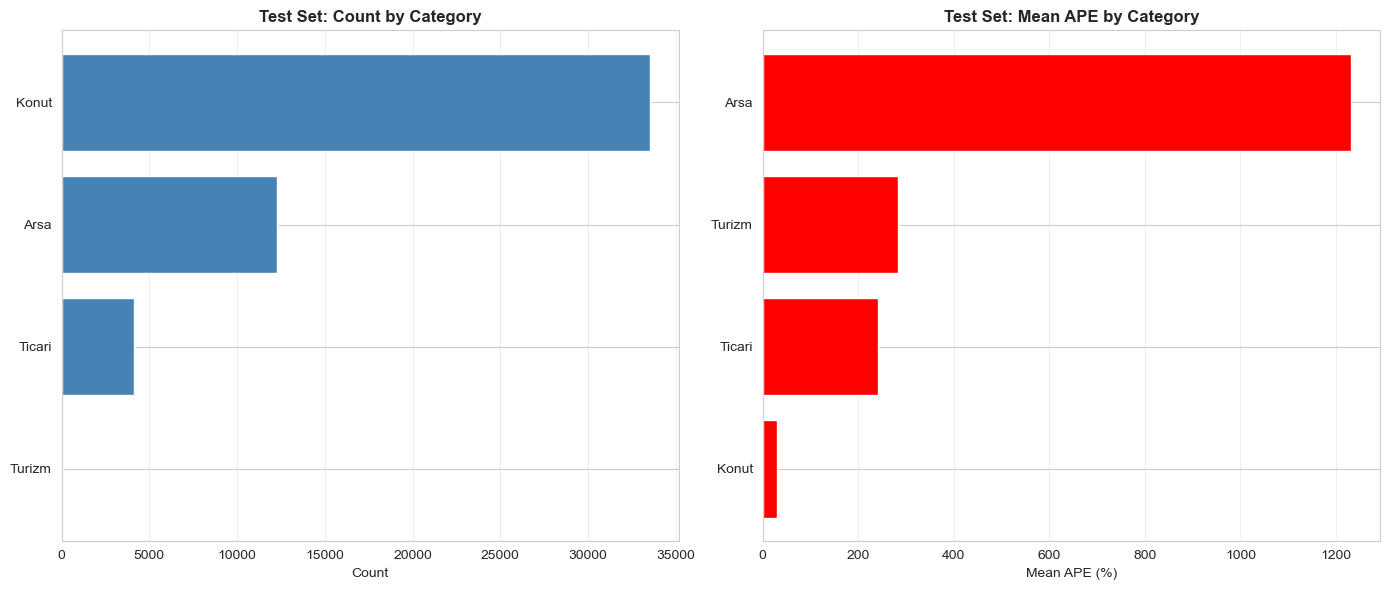


Error Analysis:
Overall test MAPE: 343.07%
Overall test Median APE: 24.25%

Categories with above-average MAPE:


,Count,Mean APE (%),Median APE (%)
category,,,
Arsa,12291,1230.48,51.25



Categories with above-average MAPE and at least 20 observations:


,Count,Mean APE (%),Median APE (%)
category,,,
Arsa,12291,1230.48,51.25


In [29]:
# Category-based error analysis on test set
print("\n" + "="*60)
print("CATEGORY-BASED TEST ERROR ANALYSIS")
print("="*60)

if "price" in test_clean.columns:
    test_analysis = test_clean[["category", "price"]].copy()
    test_analysis["predicted_price"] = test_predictions_price
    
    # Keep only valid rows
    valid_mask = (
        test_analysis["price"].notna() &
        (test_analysis["price"] > 0) &
        test_analysis["predicted_price"].notna() &
        (test_analysis["predicted_price"] > 0)
    )
    
    test_analysis = test_analysis[valid_mask].copy()
    
    # Calculate errors
    test_analysis["absolute_error"] = (
        test_analysis["price"] - test_analysis["predicted_price"]
    ).abs()
    
    test_analysis["absolute_percentage_error"] = (
        test_analysis["absolute_error"] / test_analysis["price"]
    ) * 100
    
    # Group by category
    category_analysis = test_analysis.groupby("category", dropna=False).agg({
        "price": ["count", "mean", "median"],
        "predicted_price": ["mean", "median"],
        "absolute_error": ["mean", "median"],
        "absolute_percentage_error": ["mean", "median"]
    }).round(2)
    
    category_analysis.columns = [
        "Count", "Mean Actual Price", "Median Actual Price",
        "Mean Predicted Price", "Median Predicted Price",
        "Mean Absolute Error", "Median Absolute Error",
        "Mean APE (%)", "Median APE (%)"
    ]
    
    category_analysis = category_analysis.sort_values("Mean APE (%)", ascending=False)
    
    print("\nPerformance by Property Category:")
    display(category_analysis)
    
    # Visualize category performance
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Count by category
    cat_counts = test_analysis["category"].value_counts(dropna=False).sort_values(ascending=True)
    axes[0].barh(cat_counts.index.astype(str), cat_counts.values, color="steelblue")
    axes[0].set_title("Test Set: Count by Category", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Count")
    axes[0].grid(True, alpha=0.3, axis="x")
    
    # MAPE by category
    mape_by_cat = (
        test_analysis.groupby("category", dropna=False)["absolute_percentage_error"]
        .mean()
        .sort_values(ascending=True)
    )
    
    axes[1].barh(mape_by_cat.index.astype(str), mape_by_cat.values, color="red")
    axes[1].set_title("Test Set: Mean APE by Category", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Mean APE (%)")
    axes[1].grid(True, alpha=0.3, axis="x")
    
    plt.tight_layout()
    plt.show()
    
    # Identify problematic categories
    print("\nError Analysis:")
    overall_mape = test_analysis["absolute_percentage_error"].mean()
    overall_median_ape = test_analysis["absolute_percentage_error"].median()
    
    print(f"Overall test MAPE: {overall_mape:.2f}%")
    print(f"Overall test Median APE: {overall_median_ape:.2f}%")
    
    print("\nCategories with above-average MAPE:")
    above_avg = category_analysis[category_analysis["Mean APE (%)"] > overall_mape]
    display(above_avg[["Count", "Mean APE (%)", "Median APE (%)"]])
    
    print("\nCategories with above-average MAPE and at least 20 observations:")
    above_avg_reliable = above_avg[above_avg["Count"] >= 20]
    display(above_avg_reliable[["Count", "Mean APE (%)", "Median APE (%)"]])

else:
    print("\nNote: Test dataset does not contain price information.")
    print("Category-based error analysis cannot be calculated.")

In [30]:
# Price-segment error analysis
print("\n" + "="*60)
print("PRICE-SEGMENT ERROR ANALYSIS")
print("="*60)

if "price" in test_clean.columns:
    
    # If test_analysis was not created in the previous cell, create it here
    if "test_analysis" not in globals():
        test_analysis = test_clean[["category", "price"]].copy()
        test_analysis["predicted_price"] = test_predictions_price
        
        valid_mask = (
            test_analysis["price"].notna() &
            (test_analysis["price"] > 0) &
            test_analysis["predicted_price"].notna() &
            (test_analysis["predicted_price"] > 0)
        )
        
        test_analysis = test_analysis[valid_mask].copy()
        test_analysis["absolute_error"] = (
            test_analysis["price"] - test_analysis["predicted_price"]
        ).abs()
        test_analysis["absolute_percentage_error"] = (
            test_analysis["absolute_error"] / test_analysis["price"]
        ) * 100
    
    # Create price segments based on actual test prices
    test_analysis["price_segment"] = pd.qcut(
        test_analysis["price"],
        q=10,
        duplicates="drop"
    )
    
    price_segment_analysis = test_analysis.groupby("price_segment", observed=False).agg(
        count=("price", "count"),
        mean_actual_price=("price", "mean"),
        median_actual_price=("price", "median"),
        mean_predicted_price=("predicted_price", "mean"),
        median_predicted_price=("predicted_price", "median"),
        mean_absolute_error=("absolute_error", "mean"),
        median_absolute_error=("absolute_error", "median"),
        mean_ape=("absolute_percentage_error", "mean"),
        median_ape=("absolute_percentage_error", "median")
    ).round(2)
    
    print("\nPerformance by Price Segment:")
    display(price_segment_analysis)
    
    print("\nOverall mean APE:", round(test_analysis["absolute_percentage_error"].mean(), 2))
    print("Overall median APE:", round(test_analysis["absolute_percentage_error"].median(), 2))
    
    print("\nTop 20 highest percentage errors:")
    display(
        test_analysis.sort_values("absolute_percentage_error", ascending=False)
        .head(20)
    )

else:
    print("\nNote: Test dataset does not contain price information.")
    print("Price-segment error analysis cannot be calculated.")


PRICE-SEGMENT ERROR ANALYSIS

Performance by Price Segment:


,count,mean_actual_price,median_actual_price,mean_predicted_price,median_predicted_price,mean_absolute_error,median_absolute_error,mean_ape,median_ape
price_segment,,,,,,,,,
"(35.999, 145000.0]",5120,92965.51,100000.0,243296.92,154242.33,155386.47,52188.21,3034.82,58.72
"(145000.0, 210000.0]",5233,178852.78,179000.0,243323.47,209078.49,80151.34,39330.42,45.63,22.05
"(210000.0, 261400.0]",4647,238500.70,240000.0,284626.59,256036.26,75451.92,40403.07,31.74,16.93
"(261400.0, 320000.0]",5070,291120.43,290000.0,333778.74,298300.72,88228.32,47367.12,30.24,16.26
"(320000.0, 390000.0]",5120,355856.31,355000.0,382706.47,351023.70,95891.99,59969.39,26.95,16.90
"(390000.0, 490000.0]",4880,438308.60,440000.0,464415.94,420258.15,130264.75,82990.63,29.67,18.88
"(490000.0, 660000.0]",4939,572318.35,565000.0,596473.76,535430.67,185818.72,121471.72,32.46,21.41
"(660000.0, 1050000.0]",5071,828769.38,819000.0,821495.04,722172.40,308165.54,215357.57,36.81,26.71
"(1050000.0, 2195800.0]",4919,1502754.98,1455000.0,1341601.63,1178134.15,612106.57,479755.82,40.43,32.55



Overall mean APE: 343.07
Overall median APE: 24.25

Top 20 highest percentage errors:


,category,price,predicted_price,absolute_error,absolute_percentage_error,price_segment
17536,Arsa,200.0,6.540417e+06,6.540217e+06,3.270108e+06,"(35.999, 145000.0]"
27550,Arsa,1000.0,9.244905e+06,9.243905e+06,9.243905e+05,"(35.999, 145000.0]"
15107,Arsa,100.0,8.083370e+05,8.082370e+05,8.082370e+05,"(35.999, 145000.0]"
39384,Arsa,47.0,2.848291e+05,2.847821e+05,6.059194e+05,"(35.999, 145000.0]"
31896,Arsa,1111.0,4.613287e+06,4.612176e+06,4.151373e+05,"(35.999, 145000.0]"
18399,Arsa,5500.0,2.121564e+07,2.121014e+07,3.856388e+05,"(35.999, 145000.0]"
902,Arsa,295.0,9.834283e+05,9.831333e+05,3.332655e+05,"(35.999, 145000.0]"
21618,Arsa,3000.0,9.117477e+06,9.114477e+06,3.038159e+05,"(35.999, 145000.0]"
21706,Arsa,100.0,2.994892e+05,2.993892e+05,2.993892e+05,"(35.999, 145000.0]"
21167,Arsa,117.0,3.346975e+05,3.345805e+05,2.859662e+05,"(35.999, 145000.0]"


## 18. Save Final Predictions

In [31]:
# Create prediction dataframe
prediction_df = pd.DataFrame({
    "Predicted Price": test_predictions_price
})

# Add externalId from original test dataframe, because test_clean drops it during cleaning
if "externalId" in test_df.columns:
    assert len(test_df) == len(prediction_df), "test_df and predictions have different lengths!"
    prediction_df.insert(0, "externalId", test_df["externalId"].values)

# Add actual price only for checking/evaluation
if "price" in test_df.columns:
    prediction_df["Actual Price"] = test_df["price"].values
    
    valid_actual_mask = (
        prediction_df["Actual Price"].notna() &
        (prediction_df["Actual Price"] > 0)
    )
    
    prediction_df["APE (%)"] = np.nan
    prediction_df.loc[valid_actual_mask, "APE (%)"] = (
        np.abs(
            prediction_df.loc[valid_actual_mask, "Actual Price"] -
            prediction_df.loc[valid_actual_mask, "Predicted Price"]
        ) / prediction_df.loc[valid_actual_mask, "Actual Price"]
    ) * 100

# Save detailed prediction file for your own checking
prediction_df.to_csv("zingat2020_predictions_detailed.csv", index=False)

# Save clean prediction file for possible official submission
submission_cols = []

if "externalId" in prediction_df.columns:
    submission_cols.append("externalId")

submission_cols.append("Predicted Price")

submission_df = prediction_df[submission_cols].copy()
submission_df.to_csv("zingat2020_predictions.csv", index=False)

print("="*60)
print("PREDICTIONS SAVED")
print("="*60)
print("Detailed file: zingat2020_predictions_detailed.csv")
print("Submission file: zingat2020_predictions.csv")
print(f"Rows: {len(prediction_df)}")
print(f"Detailed columns: {list(prediction_df.columns)}")
print(f"Submission columns: {list(submission_df.columns)}")

print("\nFirst 10 detailed predictions:")
display(prediction_df.head(10))

PREDICTIONS SAVED
Detailed file: zingat2020_predictions_detailed.csv
Submission file: zingat2020_predictions.csv
Rows: 50000
Detailed columns: ['externalId', 'Predicted Price', 'Actual Price', 'APE (%)']
Submission columns: ['externalId', 'Predicted Price']

First 10 detailed predictions:


,externalId,Predicted Price,Actual Price,APE (%)
0,zingat-3201030,7.281907e+05,700000.0,4.027244
1,zingat-2611061,2.994131e+05,850000.0,64.774924
2,zingat-2836742,3.638032e+05,315000.0,15.493071
3,zingat-3201023,6.505747e+05,550000.0,18.286314
4,zingat-2871696,1.068577e+06,999000.0,6.964667
5,zingat-3017794,2.348421e+05,68000.0,245.355961
6,zingat-3086789,2.672052e+05,260000.0,2.771242
7,zingat-2836016,3.138792e+05,245000.0,28.113965
8,zingat-2129659,9.281740e+05,835000.0,11.158565
9,zingat-3017932,4.381294e+05,450000.0,2.637904


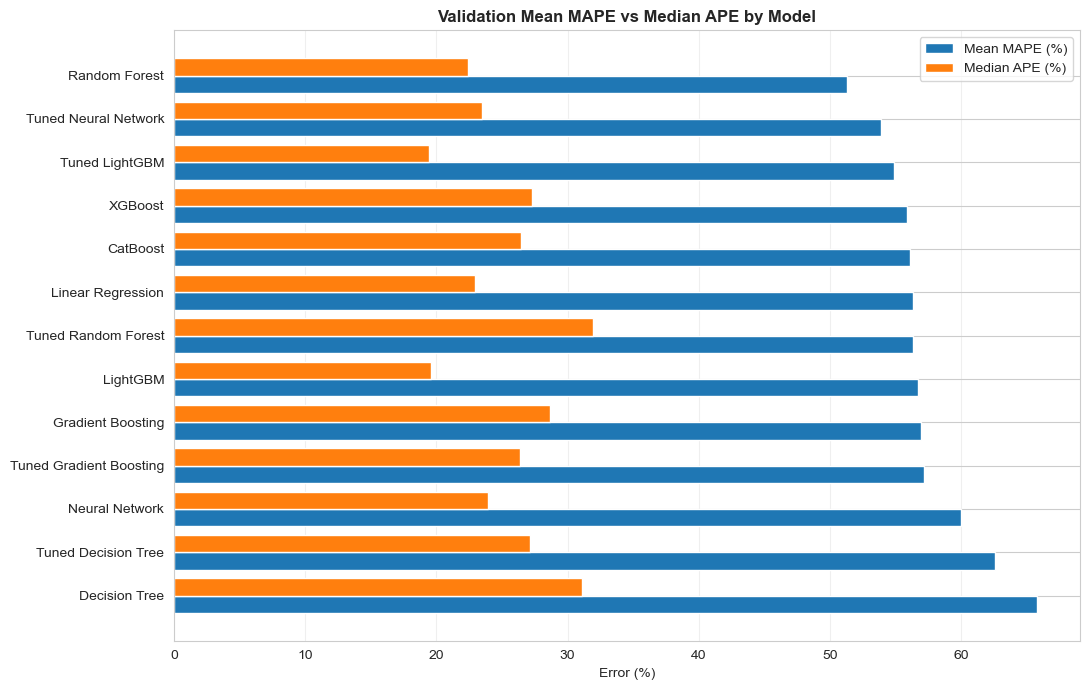

In [ ]:
# Model Visual: Validation Mean MAPE vs Median APE

model_error_compare = final_results_df.sort_values("Val MAPE (%)", ascending=False).copy()

fig, ax = plt.subplots(figsize=(11, 7))

bar_width = 0.4
y_pos = np.arange(len(model_error_compare))

ax.barh(
    y_pos - bar_width/2,
    model_error_compare["Val MAPE (%)"],
    height=bar_width,
    label="Mean MAPE (%)"
)

ax.barh(
    y_pos + bar_width/2,
    model_error_compare["Val Median APE (%)"],
    height=bar_width,
    label="Median APE (%)"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(model_error_compare["Model"])
ax.set_xlabel("Error (%)")
ax.set_title("Validation Mean MAPE vs Median APE by Model", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
ax.legend()

plt.tight_layout()
plt.show()

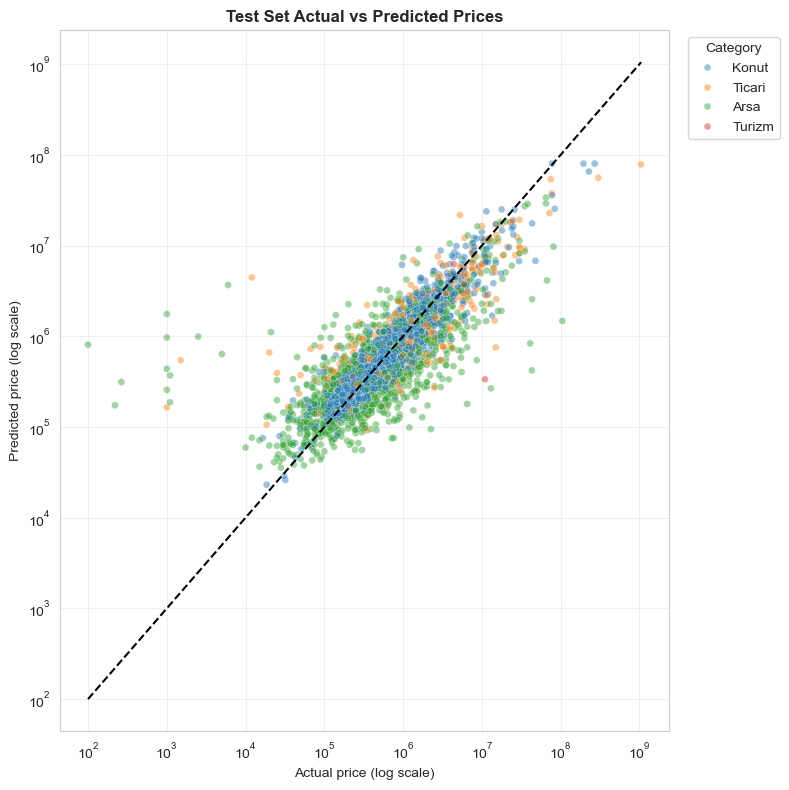

In [ ]:
# Test Visual: Actual vs predicted prices on the test set

if "price" in test_clean.columns and "test_analysis" in globals():
    test_plot_sample = test_analysis.sample(
        n=min(5000, len(test_analysis)),
        random_state=RANDOM_STATE
    )

    plt.figure(figsize=(8, 8))

    sns.scatterplot(
        data=test_plot_sample,
        x="price",
        y="predicted_price",
        hue="category",
        alpha=0.45,
        s=25
    )

    min_val = min(test_plot_sample["price"].min(), test_plot_sample["predicted_price"].min())
    max_val = max(test_plot_sample["price"].max(), test_plot_sample["predicted_price"].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", linewidth=1.5)

    plt.xscale("log")
    plt.yscale("log")
    plt.title("Test Set Actual vs Predicted Prices", fontsize=12, fontweight="bold")
    plt.xlabel("Actual price (log scale)")
    plt.ylabel("Predicted price (log scale)")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Test actual prices or test_analysis are not available, so this plot cannot be created.")